# CRC-CQR: Cost-Optimal GPU Allocation via Conformal Risk Control



**Dataset:** Alibaba PAI GPU Trace 2020, features from ATLAS (ICLR 2026)

In [ ]:
!pip install lightgbm

## 1. Configuration

In [ ]:
# =============================================================
# CONFIGURATION
# =============================================================
# Cost model: waste + R × overrun
#   waste = max(alloc - actual, 0)  — idle GPU-seconds
#   overrun = max(actual - alloc, 0) — job exceeds allocation
#   R = operator-specified cost ratio (how much worse is violation than waste)
#
# Real-world cost context (AWS, 2025-2026):
#   p4d.24xlarge (8x A100): ~$22-33/hr = $0.006-0.009/GPU-second
#   Violation: job killed, ALL compute lost, must restart from scratch
#   Waste: reserved GPU sits idle until allocation expires
#   R ≈ 2-5 (checkpointed training) to 10-100 (bare inference with SLAs)

# --- Data paths ---
ARCHIVES = [
    "/content/pai_group_tag_table.tar.gz",
    "/content/pai_job_table.tar.gz",
    "/content/pai_task_table.tar.gz",
]
EXTRACT_DIR_PATH = "/content/extracted"

# --- Data splits (chronological, no leakage) ---
TRAIN_FRAC = 0.55
CAL_FRAC   = 0.15
VAL_FRAC   = 0.15

# --- LightGBM ---
LGBM_PARAMS = dict(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1,
)
QUANTILE_LO = 0.05
QUANTILE_HI = 0.95

# --- Lambda grid (CRC scales CQR intervals) ---
# lambda=0: allocate CQR midpoint (aggressive)
# lambda=1: standard CQR 90% coverage
# lambda>1: beyond CQR (conservative)
LAMBDA_GRID = (0.0, 5.0, 1000)

# --- Scheduling ---
SCHED_SAMPLE_SIZE = 10000

# --- Misc ---
RNG = 42
PREVIEW_ON_VAL = True

print("Config loaded.")
print(f"  Splits: {TRAIN_FRAC:.0%}/{CAL_FRAC:.0%}/{VAL_FRAC:.0%}/{1-TRAIN_FRAC-CAL_FRAC-VAL_FRAC:.0%}")
print(f"  Lambda grid: {LAMBDA_GRID[0]} to {LAMBDA_GRID[1]}, {LAMBDA_GRID[2]} steps")


Config loaded.
  Splits: 55%/15%/15%/15%
  Lambda grid: 0.0 to 5.0, 1000 steps


## 2. Data Loading & Feature Engineering

Features follow ATLAS (ICLR 2026) leakage-free design: only submit-time information available to the scheduler.

In [ ]:
# =============================================================
# DATA LOADING & LEAKAGE-FREE FEATURE ENGINEERING
# =============================================================
import tarfile, pathlib, warnings, time, gc
from dataclasses import dataclass
from typing import Dict, List, Tuple
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import heapq

warnings.filterwarnings("ignore")
np.random.seed(RNG)
EXTRACT_DIR = pathlib.Path(EXTRACT_DIR_PATH)

def extract_archives():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    for gz in ARCHIVES:
        with tarfile.open(gz, mode="r:gz") as tar:
            tar.extractall(path=EXTRACT_DIR)

def load_tables():
    job_cols  = ["job_name","inst_id","user","status","start_time","end_time"]
    task_cols = ["job_name","task_name","inst_num","status","start_time","end_time",
                 "plan_cpu","plan_mem","plan_gpu","gpu_type"]
    grp_cols  = ["inst_id","user_from_group_table","gpu_type_spec","group","workload"]
    job  = pd.read_csv(EXTRACT_DIR/"pai_job_table.csv",  header=None, names=job_cols,  low_memory=False)
    task = pd.read_csv(EXTRACT_DIR/"pai_task_table.csv", header=None, names=task_cols, low_memory=False)
    gtag = pd.read_csv(EXTRACT_DIR/"pai_group_tag_table.csv", header=None, names=grp_cols, low_memory=False)
    job  = job[job.status=="Terminated"].copy()
    task = task[task.status=="Terminated"].copy()
    for d in (job, task):
        d["start_time"] = pd.to_numeric(d["start_time"], errors="coerce")
        d["end_time"]   = pd.to_numeric(d["end_time"],   errors="coerce")
    job.dropna(subset=["start_time","end_time"], inplace=True)
    for c in ["inst_num","plan_cpu","plan_mem","plan_gpu"]:
        task[c] = pd.to_numeric(task[c], errors="coerce").fillna(0)
    tspan = (task.groupby(["job_name","task_name"])
                  .agg(s_t=("start_time","min"), e_t=("end_time","max"),
                       inst_num=("inst_num","sum"), plan_cpu=("plan_cpu","sum"),
                       plan_mem=("plan_mem","sum"), plan_gpu=("plan_gpu","sum"))
                  .reset_index())
    tspan["d_t"] = (tspan["e_t"] - tspan["s_t"]).clip(lower=0)
    tspan = tspan[tspan["d_t"] > 0]
    jspan = (tspan.groupby("job_name")
                  .agg(p_star=("d_t","max"), total_inst_num=("inst_num","sum"),
                       total_plan_cpu=("plan_cpu","sum"), total_plan_mem=("plan_mem","sum"),
                       total_plan_gpu=("plan_gpu","sum"), num_tasks=("task_name","nunique"))
                  .reset_index())
    base = job[["job_name","inst_id","user","start_time"]].merge(jspan, on="job_name", how="inner")
    base = base[base["p_star"] > 0].copy()
    base.rename(columns={"start_time":"submit_time"}, inplace=True)
    gkeep = gtag[["inst_id","group","workload","gpu_type_spec"]].copy()
    base = base.merge(gkeep, on="inst_id", how="left")
    for c in ["group","workload","gpu_type_spec","user"]:
        base[c] = base[c].fillna("Unknown").astype(str)
    del task, tspan, gtag; gc.collect()
    return base

def time_split_4way(df, train_frac, cal_frac, val_frac):
    q1, q2, q3 = train_frac, train_frac+cal_frac, train_frac+cal_frac+val_frac
    cuts = df["submit_time"].quantile([q1, q2, q3]).values
    t_tr, t_cal, t_val = int(cuts[0]), int(cuts[1]), int(cuts[2])
    idx_tr  = df.index[df["submit_time"] < t_tr]
    idx_cal = df.index[(df["submit_time"] >= t_tr)  & (df["submit_time"] < t_cal)]
    idx_va  = df.index[(df["submit_time"] >= t_cal) & (df["submit_time"] < t_val)]
    idx_te  = df.index[df["submit_time"] >= t_val]
    return (idx_tr, idx_cal, idx_va, idx_te), (t_tr, t_cal, t_val)

def add_core_features(df):
    df = df.copy()
    for c in ["total_inst_num","total_plan_cpu","total_plan_mem","total_plan_gpu","num_tasks"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    for c in ["total_plan_cpu","total_plan_gpu","total_plan_mem","total_inst_num","num_tasks"]:
        df[f"log1p_{c}"] = np.log1p(df[c])
    df["cpu_per_inst"]   = df["total_plan_cpu"] / np.maximum(1.0, df["total_inst_num"])
    df["mem_per_gpu"]    = df["total_plan_mem"] / np.maximum(1.0, df["total_plan_gpu"])
    df["tasks_per_inst"] = df["num_tasks"]      / np.maximum(1.0, df["total_inst_num"])
    hour = ((df["submit_time"]//3600) % 24).astype(int)
    wday = (((df["submit_time"]//3600)//24) % 7).astype(int)
    how  = (wday*24 + hour).astype(int)
    df["hour"] = hour; df["wday"] = wday; df["how"] = how
    df["sin24"]  = np.sin(2*np.pi*hour/24.0)
    df["cos24"]  = np.cos(2*np.pi*hour/24.0)
    df["sin168"] = np.sin(2*np.pi*how/168.0)
    df["cos168"] = np.cos(2*np.pi*how/168.0)
    return df

def add_causal_histories(df, t_train):
    df = df.sort_values("submit_time").reset_index(drop=True).copy()
    df["y_log"] = np.log1p(df["p_star"].clip(lower=0))
    mu0 = df.loc[df["submit_time"] < t_train, "y_log"].mean()
    if not np.isfinite(mu0): mu0 = df["y_log"].mean()
    for key in ["group","user"]:
        pref = "grp" if key=="group" else "usr"
        grp = df.groupby(key)
        csum = grp["y_log"].cumsum().shift(1)
        cnt  = grp.cumcount()
        df[f"{pref}_hist_mean"]  = (csum / cnt.replace(0, np.nan)).fillna(mu0)
        df[f"{pref}_hist_count"] = cnt.astype(float)
        last_ts = grp["submit_time"].shift(1)
        df[f"{pref}_dt_prev_log1p"] = np.log1p((df["submit_time"] - last_ts).fillna(0))
    for w in (3,5,10):
        df[f"grp_roll_mean_w{w}"] = (df.groupby("group")["y_log"]
                                       .apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
                                       .reset_index(level=0, drop=True).fillna(mu0))
    n = df["grp_hist_count"].values; mu = df["grp_hist_mean"].values; lam = 10.0
    df["grp_mean_eb"] = (n*mu + lam*mu0) / (n + lam)
    return df, float(mu0)

def fit_scale_buckets(train_s, qs):
    edges = np.quantile(train_s, qs).tolist()
    def bucketize(s): return np.searchsorted(edges, s, side="right").astype(int)
    return edges, bucketize

def build_feature_table(df_raw, idx_tr, t_train):
    df = add_core_features(df_raw)
    df, mu0 = add_causal_histories(df, t_train)
    ie, ib = fit_scale_buckets(df.loc[idx_tr,"total_inst_num"], [0.5,0.9,0.99])
    ge, gb = fit_scale_buckets(df.loc[idx_tr,"total_plan_gpu"], [0.5,0.9,0.99])
    df["inst_bucket"]  = ib(df["total_inst_num"])
    df["gpu_bucket"]   = gb(df["total_plan_gpu"])
    df["scale_bucket"] = np.maximum(df["inst_bucket"], df["gpu_bucket"])
    def map_from_train(series, train_idx):
        cats = pd.Index(series.loc[train_idx].astype(str).unique())
        mapping = {c:i for i,c in enumerate(cats)}
        return series.astype(str).map(mapping).fillna(len(mapping)).astype(int)
    for c in ["user","group","workload","gpu_type_spec"]:
        df[f"{c}_code"] = map_from_train(df[c], idx_tr)
    FEATURES = [
        "log1p_total_plan_cpu","log1p_total_plan_gpu","log1p_total_plan_mem",
        "log1p_total_inst_num","log1p_num_tasks",
        "cpu_per_inst","mem_per_gpu","tasks_per_inst",
        "sin24","cos24","sin168","cos168","wday","hour",
        "inst_bucket","gpu_bucket","scale_bucket",
        "grp_hist_mean","grp_hist_count","grp_mean_eb",
        "grp_roll_mean_w3","grp_roll_mean_w5","grp_roll_mean_w10",
        "grp_dt_prev_log1p","usr_hist_mean","usr_hist_count","usr_dt_prev_log1p",
        "user_code","group_code","workload_code","gpu_type_spec_code",
    ]
    df[FEATURES] = df[FEATURES].replace([np.inf,-np.inf], np.nan).fillna(0.0)
    return df, FEATURES, mu0

# --- Run ---
print("=" * 60)
print("LOADING DATA AND BUILDING FEATURES")
print("=" * 60)
t0 = time.time()
extract_archives()
df_raw = load_tables()
print(f"Loaded jobs: {len(df_raw):,}")

splits, (t_tr, t_cal, t_val) = time_split_4way(df_raw, TRAIN_FRAC, CAL_FRAC, VAL_FRAC)
idx_tr, idx_cal, idx_va, idx_te = splits
print(f"Splits: train={len(idx_tr):,} | cal={len(idx_cal):,} | val={len(idx_va):,} | test={len(idx_te):,}")

df, FEATS, mu0 = build_feature_table(df_raw, idx_tr, t_tr)

y_log_all = np.log1p(df["p_star"].values)
X_tr, y_tr_log   = df.loc[idx_tr, FEATS], y_log_all[idx_tr]
X_cal, y_cal_log  = df.loc[idx_cal, FEATS], y_log_all[idx_cal]
X_va, y_va_log    = df.loc[idx_va, FEATS], y_log_all[idx_va]
X_te, y_te_log    = df.loc[idx_te, FEATS], y_log_all[idx_te]
y_cal_sec = df.loc[idx_cal, "p_star"].values
y_va_sec  = df.loc[idx_va, "p_star"].values
y_te_sec  = df.loc[idx_te, "p_star"].values
sub_times_te = df.loc[idx_te, "submit_time"].values.astype(float)

print(f"Data ready in {time.time()-t0:.1f}s")
print(f"Test: median={np.median(y_te_sec):.0f}s, P90={np.percentile(y_te_sec,90):.0f}s")


LOADING DATA AND BUILDING FEATURES
Loaded jobs: 732,355
Splits: train=402,795 | cal=109,852 | val=109,854 | test=109,854
Data ready in 199.7s
Test: median=674s, P90=12970s


## 3. Exploratory Data Analysis

In [ ]:
# =============================================================
# DATA EXPLORATION: What groups exist in the trace?
# =============================================================
print("=" * 60)
print("DATA EXPLORATION")
print("=" * 60)

# --- What's in the workload column? ---
print("\n1. WORKLOAD TYPES:")
wl = df.loc[idx_tr, "workload"].value_counts()
print(f"   Unique values: {len(wl)}")
for w, count in wl.head(15).items():
    pct = count / len(idx_tr) * 100
    med_rt = df.loc[(df.index.isin(idx_tr)) & (df["workload"] == w), "p_star"].median()
    print(f"   {w:<30} {count:>8} ({pct:>5.1f}%)  median runtime={med_rt:>8.0f}s")

# --- What's in the group column? ---
print(f"\n2. GROUP TAGS:")
gr = df.loc[idx_tr, "group"].value_counts()
print(f"   Unique groups: {len(gr)}")
print(f"   Top 10:")
for g, count in gr.head(10).items():
    pct = count / len(idx_tr) * 100
    med_rt = df.loc[(df.index.isin(idx_tr)) & (df["group"] == g), "p_star"].median()
    print(f"   {str(g)[:40]:<40} {count:>8} ({pct:>5.1f}%)  median={med_rt:>8.0f}s")
print(f"   Groups with >100 jobs: {(gr >= 100).sum()}")
print(f"   Groups with >1000 jobs: {(gr >= 1000).sum()}")

# --- GPU type spec ---
print(f"\n3. GPU TYPES:")
gt = df.loc[idx_tr, "gpu_type_spec"].value_counts()
for g, count in gt.items():
    pct = count / len(idx_tr) * 100
    print(f"   {str(g):<20} {count:>8} ({pct:>5.1f}%)")

# --- Instance count distribution ---
print(f"\n4. INSTANCE COUNT (gang scheduling indicator):")
inst = df.loc[idx_tr, "total_inst_num"]
for label, lo, hi in [("1 instance", 0.5, 1.5), ("2-5", 1.5, 5.5),
                        ("6-10", 5.5, 10.5), ("11-50", 10.5, 50.5),
                        ("51-100", 50.5, 100.5), (">100", 100.5, 1e9)]:
    mask = (inst >= lo) & (inst < hi)
    n = mask.sum()
    if n > 0:
        med_rt = df.loc[idx_tr[mask], "p_star"].median()
        print(f"   {label:<15} {n:>8} ({n/len(idx_tr)*100:>5.1f}%)  median runtime={med_rt:>8.0f}s")

# --- Number of tasks per job ---
print(f"\n5. TASKS PER JOB:")
nt = df.loc[idx_tr, "num_tasks"]
for label, lo, hi in [("1 task", 0.5, 1.5), ("2 tasks", 1.5, 2.5),
                       ("3-5", 2.5, 5.5), ("6-10", 5.5, 10.5), (">10", 10.5, 1e9)]:
    mask = (nt >= lo) & (nt < hi)
    n = mask.sum()
    if n > 0:
        med_rt = df.loc[idx_tr[mask], "p_star"].median()
        print(f"   {label:<15} {n:>8} ({n/len(idx_tr)*100:>5.1f}%)  median runtime={med_rt:>8.0f}s")

# --- GPU demand distribution ---
print(f"\n6. GPU DEMAND (total_plan_gpu):")
gpu = df.loc[idx_tr, "total_plan_gpu"]
for label, lo, hi in [("No GPU (0)", -0.1, 0.1), ("Fractional (0-100)", 0.1, 100),
                       ("1-2 GPU (100-200)", 100, 200), ("2-8 GPU (200-800)", 200, 800),
                       (">8 GPU (800+)", 800, 1e9)]:
    mask = (gpu >= lo) & (gpu < hi)
    n = mask.sum()
    if n > 0:
        med_rt = df.loc[idx_tr[mask], "p_star"].median()
        print(f"   {label:<25} {n:>8} ({n/len(idx_tr)*100:>5.1f}%)  median runtime={med_rt:>8.0f}s")

# --- Runtime distribution by natural clusters ---
print(f"\n7. RUNTIME DISTRIBUTION:")
rt = df.loc[idx_tr, "p_star"]
for label, lo, hi in [("<1 min", 0, 60), ("1-10 min", 60, 600),
                       ("10-60 min", 600, 3600), ("1-6 hr", 3600, 21600),
                       ("6-24 hr", 21600, 86400), (">24 hr", 86400, 1e9)]:
    mask = (rt >= lo) & (rt < hi)
    n = mask.sum()
    if n > 0:
        print(f"   {label:<15} {n:>8} ({n/len(idx_tr)*100:>5.1f}%)")

# --- Cross-tab: workload type vs runtime bucket ---
print(f"\n8. WORKLOAD vs RUNTIME (top 5 workloads):")
df_tr = df.loc[idx_tr].copy()
df_tr["rt_bucket"] = pd.cut(df_tr["p_star"],
                             bins=[0, 60, 600, 3600, 86400, 1e9],
                             labels=["<1m", "1-10m", "10-60m", "1-24h", ">24h"])
top_wl = df_tr["workload"].value_counts().head(5).index
ct = pd.crosstab(df_tr[df_tr["workload"].isin(top_wl)]["workload"],
                  df_tr[df_tr["workload"].isin(top_wl)]["rt_bucket"],
                  normalize="index") * 100
print(ct.round(1).to_string())

# --- Recurrence analysis ---
print(f"\n9. RECURRENCE (how many times has this group been seen?):")
gc = df.loc[idx_tr].groupby("group").size()
for label, lo, hi in [("First time (1)", 0.5, 1.5), ("2-5 times", 1.5, 5.5),
                       ("6-20 times", 5.5, 20.5), ("21-100", 20.5, 100.5),
                       (">100 times", 100.5, 1e9)]:
    mask = (gc >= lo) & (gc < hi)
    n_groups = mask.sum()
    n_jobs = gc[mask].sum()
    print(f"   {label:<20} {n_groups:>6} groups, {n_jobs:>8} jobs ({n_jobs/len(idx_tr)*100:>5.1f}%)")

print("\n" + "=" * 60)
print("Use these insights to define groups for per-group CRC-CQR.")
print("Good candidates: workload type, instance count, GPU demand, recurrence.")
print("=" * 60)


DATA EXPLORATION

1. WORKLOAD TYPES:
   Unique values: 10
   Unknown                          355354 ( 88.2%)  median runtime=     617s
   bert                              23332 (  5.8%)  median runtime=     750s
   ctr                               15114 (  3.8%)  median runtime=    1067s
   nmt                                4759 (  1.2%)  median runtime=    8599s
   inception                          2913 (  0.7%)  median runtime=     363s
   graphlearn                          879 (  0.2%)  median runtime=    3660s
   resnet                              206 (  0.1%)  median runtime=     934s
   xlnet                               178 (  0.0%)  median runtime=   13232s
   rl                                   46 (  0.0%)  median runtime=     162s
   vgg                                  14 (  0.0%)  median runtime=   15646s

2. GROUP TAGS:
   Unique groups: 127956
   Top 10:
   7755b21bfabe33c2399770fd4f3be0f9            11937 (  3.0%)  median=     369s
   f60780653e1f3281896a94ba042

## 4. Model Training

Three LightGBM quantile regressors (alpha=0.05, 0.50, 0.95) trained on log1p(runtime).

In [ ]:
# =============================================================
# MODEL TRAINING
# =============================================================
from sklearn.metrics import r2_score
print("=" * 60)
print("TRAINING MODELS")
print("=" * 60)

es_set = [(X_va.values if hasattr(X_va,'values') else X_va, y_va_log)]

print("  Training median model...")
model_med = LGBMRegressor(objective="quantile", alpha=0.5, random_state=RNG, **LGBM_PARAMS)
model_med.fit(X_tr, y_tr_log, eval_set=es_set, callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])

print(f"  Training lower quantile (alpha={QUANTILE_LO})...")
model_lo = LGBMRegressor(objective="quantile", alpha=QUANTILE_LO, random_state=RNG, **LGBM_PARAMS)
model_lo.fit(X_tr, y_tr_log, eval_set=es_set, callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])

print(f"  Training upper quantile (alpha={QUANTILE_HI})...")
model_hi = LGBMRegressor(objective="quantile", alpha=QUANTILE_HI, random_state=RNG, **LGBM_PARAMS)
model_hi.fit(X_tr, y_tr_log, eval_set=es_set, callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])

# Predictions on all splits (seconds)
pred_med_cal = np.expm1(model_med.predict(X_cal)).clip(min=1.0)
pred_med_va  = np.expm1(model_med.predict(X_va)).clip(min=1.0)
pred_med_te  = np.expm1(model_med.predict(X_te)).clip(min=1.0)

pred_lo_cal_log = model_lo.predict(X_cal)
pred_hi_cal_log = model_hi.predict(X_cal)
pred_lo_te_log  = model_lo.predict(X_te)
pred_hi_te_log  = model_hi.predict(X_te)
pred_lo_va_log  = model_lo.predict(X_va)
pred_hi_va_log  = model_hi.predict(X_va)

# Feature importance
importances = model_med.feature_importances_
feat_imp = sorted(zip(FEATS, importances), key=lambda x: -x[1])
print("\nTop 10 features:")
for f, imp in feat_imp[:10]:
    print(f"  {f:<30} {imp:>5}")

print(f"\nPoint prediction (test): MAE={mean_absolute_error(y_te_sec, pred_med_te):.0f}s, "
      f"R2(log)={r2_score(y_te_log, model_med.predict(X_te)):.3f}, "
      f"within25%={(np.abs(pred_med_te-y_te_sec)/np.maximum(y_te_sec,1)<=0.25).mean()*100:.1f}%")


TRAINING MODELS
  Training median model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4209
[LightGBM] [Info] Number of data points in the train set: 402795, number of used features: 31
[LightGBM] [Info] Start training from score 6.489205
  Training lower quantile (alpha=0.05)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.130568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4209
[LightGBM] [Info] Number of data points in the train set: 402795, number of used features: 31
[LightGBM] [Info] Start training from score 3.367296
  Training upper quantile (alpha=0.95)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129845 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total B

### 4.1 Cost Decomposition

Where does scheduling cost come from? Which jobs drive cost?

## 5. Revised CRC-CQR Calibration

In [ ]:
# =============================================================
# REVISED CRC-CQR: PROPER CONSTRAINED FORMULATION
# =============================================================
from scipy import stats as scipy_stats

print("=" * 70)
print("CQR BASE INTERVALS + PROPER CRC")
print("=" * 70)

# --- CQR calibration (unchanged) ---
def cqr_calibrate(pred_lo_log, pred_hi_log, y_true_log, alpha):
    E = np.maximum(pred_lo_log - y_true_log, y_true_log - pred_hi_log)
    return np.quantile(E, 1 - alpha)

Q_cqr = cqr_calibrate(pred_lo_cal_log, pred_hi_cal_log, y_cal_log, 0.10)
print(f"  CQR Q = {Q_cqr:.4f}")

# Build CQR intervals in seconds
cqr_lo_cal_sec = np.expm1(pred_lo_cal_log - Q_cqr).clip(min=0)
cqr_hi_cal_sec = np.expm1(pred_hi_cal_log + Q_cqr).clip(min=0)
cqr_lo_te_sec  = np.expm1(pred_lo_te_log - Q_cqr).clip(min=0)
cqr_hi_te_sec  = np.expm1(pred_hi_te_log + Q_cqr).clip(min=0)

mid_cal = (cqr_lo_cal_sec + cqr_hi_cal_sec) / 2.0
hw_cal  = (cqr_hi_cal_sec - cqr_lo_cal_sec) / 2.0
mid_te  = (cqr_lo_te_sec + cqr_hi_te_sec) / 2.0
hw_te   = (cqr_hi_te_sec - cqr_lo_te_sec) / 2.0

# Lambda grid (extended for high R)
lambdas = np.linspace(0.0, 8.0, 2000)

# --- Cost decomposition functions ---
def compute_cost(alloc, y_true, R):
    return np.maximum(alloc - y_true, 0) + R * np.maximum(y_true - alloc, 0)

def compute_waste(alloc, y_true):
    return np.maximum(alloc - y_true, 0)

def compute_overrun(alloc, y_true):
    return np.maximum(y_true - alloc, 0)

# =============================================================
# PROPER CRC: constrained overrun control
# =============================================================
# CRC (Angelopoulos et al., 2022):
#   Find smallest lambda s.t. E[L(lambda)] <= alpha
#   where L must be monotone DECREASING in lambda.
#
# Overrun L(lambda) = max(y - a(lambda), 0) IS monotone decreasing
# in lambda (more allocation -> less overrun). So CRC applies.
#
# Rule: lambda* = min{lam : mean_cal(overrun(lam)) <= alpha * n/(n+1)}
# =============================================================

n_cal = len(y_cal_sec)

def crc_find_lambda(mid, hw, y_true, lambdas, alpha):
    """
    Proper CRC: find smallest lambda such that
    mean(overrun) <= alpha * n / (n+1).

    Overrun is monotone decreasing in lambda -> guarantee holds.
    Returns (lambda*, index).
    """
    n = len(y_true)
    threshold = alpha * n / (n + 1)
    for j, lam in enumerate(lambdas):
        alloc = mid + lam * hw
        mean_overrun = np.maximum(y_true - alloc, 0).mean()
        if mean_overrun <= threshold:
            return lam, j
    return lambdas[-1], len(lambdas) - 1


def erm_find_lambda(mid, hw, y_true, lambdas, R):
    """Old approach: argmin mean cost over lambda. No guarantee."""
    costs = np.zeros(len(lambdas))
    for j, lam in enumerate(lambdas):
        alloc = mid + lam * hw
        costs[j] = compute_cost(alloc, y_true, R).mean()
    return lambdas[np.argmin(costs)], np.argmin(costs)

# --- Calibrate for each R ---
R_values = [2, 5, 10, 20, 50]

print(f"\n  Proper CRC: find smallest lambda s.t. E[overrun] <= alpha")
print(f"  Alpha derived from ERM-optimal overrun level for each R.\n")

print(f"  {'R':>5} {'tau':>6} {'alpha(s)':>10} {'CRC lam*':>10} {'ERM lam*':>10} "
      f"{'Cov':>7} {'Overrun':>10} {'Waste':>10} {'Cost(R)':>10}")
print(f"  {'-'*85}")

crc_results = {}
erm_results = {}

for R in R_values:
    tau = R / (1 + R)

    # ERM lambda (old approach)
    erm_lam, _ = erm_find_lambda(mid_cal, hw_cal, y_cal_sec, lambdas, R)

    # Alpha = mean overrun at ERM optimum (data-driven)
    alloc_erm_cal = mid_cal + erm_lam * hw_cal
    alpha_R = compute_overrun(alloc_erm_cal, y_cal_sec).mean()

    # Proper CRC lambda
    crc_lam, _ = crc_find_lambda(mid_cal, hw_cal, y_cal_sec, lambdas, alpha_R)

    # Evaluate both on test
    alloc_crc_te = mid_te + crc_lam * hw_te
    alloc_erm_te = mid_te + erm_lam * hw_te

    crc_results[R] = {
        "lambda": crc_lam, "alpha": alpha_R, "tau": tau,
        "alloc_te": alloc_crc_te,
        "cov": (y_te_sec <= alloc_crc_te).mean(),
        "overrun": compute_overrun(alloc_crc_te, y_te_sec).mean(),
        "waste": compute_waste(alloc_crc_te, y_te_sec).mean(),
        "cost": compute_cost(alloc_crc_te, y_te_sec, R).mean(),
    }
    erm_results[R] = {
        "lambda": erm_lam,
        "alloc_te": alloc_erm_te,
        "cov": (y_te_sec <= alloc_erm_te).mean(),
        "overrun": compute_overrun(alloc_erm_te, y_te_sec).mean(),
        "waste": compute_waste(alloc_erm_te, y_te_sec).mean(),
        "cost": compute_cost(alloc_erm_te, y_te_sec, R).mean(),
    }

    r = crc_results[R]
    print(f"  {R:>5} {tau:>6.3f} {alpha_R:>10,.0f} {crc_lam:>10.3f} {erm_lam:>10.3f} "
          f"{r['cov']:>6.1%} {r['overrun']:>9,.0f} {r['waste']:>9,.0f} {r['cost']:>9,.0f}")

# CRC guarantee check
print(f"\n  CRC GUARANTEE VERIFICATION (test set):")
print(f"  {'R':>5} {'alpha':>10} {'Test overrun':>12} {'Valid?':>8}")
print(f"  {'-'*40}")
for R in R_values:
    r = crc_results[R]
    valid = "YES" if r["overrun"] <= r["alpha"] * 1.05 else "DRIFT"
    print(f"  {R:>5} {r['alpha']:>10,.0f} {r['overrun']:>11,.0f} {valid:>8}")

CQR BASE INTERVALS + PROPER CRC
  CQR Q = 0.0812

  Proper CRC: find smallest lambda s.t. E[overrun] <= alpha
  Alpha derived from ERM-optimal overrun level for each R.

      R    tau   alpha(s)   CRC lam*   ERM lam*     Cov    Overrun      Waste    Cost(R)
  -------------------------------------------------------------------------------------
      2  0.667      1,434      0.004      0.000  82.4%     1,658     2,507     5,823
      5  0.833      1,183      0.252      0.248  87.5%     1,385     3,474    10,399
     10  0.909        899      0.724      0.720  92.5%     1,055     5,502    16,056
     20  0.952        628      1.557      1.553  96.2%       757     9,358    24,490
     50  0.980        353      3.422      3.418  98.3%       500    18,412    43,432

  CRC GUARANTEE VERIFICATION (test set):
      R      alpha Test overrun   Valid?
  ----------------------------------------
      2      1,434       1,658    DRIFT
      5      1,183       1,385    DRIFT
     10        899    

In [ ]:
# =============================================================
# COST DECOMPOSITION: Where does scheduling cost actually come from?
# =============================================================
# Before grouping, understand what drives cost.

print("=" * 60)
print("COST DECOMPOSITION ANALYSIS")
print("=" * 60)

# Use CQR intervals on test set
alloc_cqr = mid_te + 1.0 * hw_te  # standard CQR
waste_per_job = 1.0 * np.maximum(alloc_cqr - y_te_sec, 0)
viol_per_job  = 10.0 * np.maximum(y_te_sec - alloc_cqr, 0)
cost_per_job  = waste_per_job + viol_per_job

# What fraction of total cost comes from which jobs?
print("\n1. COST CONCENTRATION:")
total_cost = cost_per_job.sum()
sorted_costs = np.sort(cost_per_job)[::-1]
for pct in [1, 5, 10, 20, 50]:
    n = int(len(sorted_costs) * pct / 100)
    frac = sorted_costs[:n].sum() / total_cost * 100
    print(f"   Top {pct}% of jobs ({n:,} jobs) account for {frac:.1f}% of total cost")

# Which jobs have highest cost?
print("\n2. HIGH-COST JOB CHARACTERISTICS (top 5% by cost):")
top5_mask = cost_per_job >= np.percentile(cost_per_job, 95)
bot50_mask = cost_per_job <= np.median(cost_per_job)

for label, mask in [("Top 5% cost jobs", top5_mask), ("Bottom 50% cost jobs", bot50_mask)]:
    n = mask.sum()
    sub = df.loc[idx_te[mask]]
    print(f"\n   {label} (n={n:,}):")
    print(f"     Median runtime:     {sub['p_star'].median():>10.0f}s ({sub['p_star'].median()/3600:.1f}hr)")
    print(f"     Median instances:   {sub['total_inst_num'].median():>10.0f}")
    print(f"     Median GPU demand:  {sub['total_plan_gpu'].median():>10.0f}")
    print(f"     Median num_tasks:   {sub['num_tasks'].median():>10.0f}")
    print(f"     Median grp_hist_ct: {sub['grp_hist_count'].median():>10.0f}")
    print(f"     Mean cost:          {cost_per_job[mask].mean():>10.0f}")
    print(f"     Violation fraction: {(viol_per_job[mask] > 0).mean():>10.1%}")
    print(f"     Waste fraction:     {(waste_per_job[mask] > 0).mean():>10.1%}")

    # Workload distribution
    wl = sub["workload"].value_counts().head(5)
    print(f"     Top workloads: {dict(wl)}")

# Cost by observable features
print("\n3. COST BY INSTANCE COUNT:")
for label, lo, hi in [("1 inst", 0.5, 1.5), ("2-10", 1.5, 10.5),
                        ("11-50", 10.5, 50.5), ("51+", 50.5, 1e9)]:
    inst = df.loc[idx_te, "total_inst_num"].values
    mask = (inst >= lo) & (inst < hi)
    if mask.sum() == 0: continue
    c = cost_per_job[mask]
    v = viol_per_job[mask]
    w = waste_per_job[mask]
    print(f"   {label:<10} n={mask.sum():>6}  mean_cost={c.mean():>8.0f}  "
          f"viol_cost={v.mean():>8.0f}  waste_cost={w.mean():>8.0f}  "
          f"viol%={(v>0).mean():>5.1%}  total_share={c.sum()/total_cost*100:>5.1f}%")

print("\n4. COST BY GPU DEMAND:")
gpu = df.loc[idx_te, "total_plan_gpu"].values
for label, lo, hi in [("No GPU", -0.1, 0.1), ("Frac", 0.1, 100),
                        ("1-2 GPU", 100, 200), ("2-8 GPU", 200, 800), (">8 GPU", 800, 1e9)]:
    mask = (gpu >= lo) & (gpu < hi)
    if mask.sum() == 0: continue
    c = cost_per_job[mask]
    print(f"   {label:<10} n={mask.sum():>6}  mean_cost={c.mean():>8.0f}  "
          f"total_share={c.sum()/total_cost*100:>5.1f}%")

print("\n5. COST BY RECURRENCE:")
rec = df.loc[idx_te, "grp_hist_count"].values
for label, lo, hi in [("First time", -0.5, 0.5), ("2-5x", 0.5, 5.5),
                        ("6-20x", 5.5, 20.5), ("21-100x", 20.5, 100.5), (">100x", 100.5, 1e9)]:
    mask = (rec >= lo) & (rec < hi)
    if mask.sum() == 0: continue
    c = cost_per_job[mask]
    print(f"   {label:<12} n={mask.sum():>6}  mean_cost={c.mean():>8.0f}  "
          f"total_share={c.sum()/total_cost*100:>5.1f}%")

print("\n6. COST BY NUMBER OF TASKS:")
nt = df.loc[idx_te, "num_tasks"].values
for label, lo, hi in [("1 task", 0.5, 1.5), ("2 tasks", 1.5, 2.5), ("3+", 2.5, 1e9)]:
    mask = (nt >= lo) & (nt < hi)
    if mask.sum() == 0: continue
    c = cost_per_job[mask]
    print(f"   {label:<10} n={mask.sum():>6}  mean_cost={c.mean():>8.0f}  "
          f"total_share={c.sum()/total_cost*100:>5.1f}%")

print("\n7. COST BY CQR INTERVAL WIDTH (uncertainty proxy):")
widths = hw_te * 2  # full CQR interval width
for label, lo, hi in [("Narrow (<P25)", 0, np.percentile(widths, 25)),
                        ("Medium (P25-75)", np.percentile(widths, 25), np.percentile(widths, 75)),
                        ("Wide (P75-95)", np.percentile(widths, 75), np.percentile(widths, 95)),
                        ("Very wide (>P95)", np.percentile(widths, 95), 1e20)]:
    mask = (widths >= lo) & (widths < hi)
    if mask.sum() == 0: continue
    c = cost_per_job[mask]
    v = viol_per_job[mask]
    print(f"   {label:<20} n={mask.sum():>6}  mean_cost={c.mean():>8.0f}  "
          f"viol%={(v>0).mean():>5.1%}  total_share={c.sum()/total_cost*100:>5.1f}%")

print("\n8. INTERACTION: Instance count x Recurrence")
inst = df.loc[idx_te, "total_inst_num"].values
rec = df.loc[idx_te, "grp_hist_count"].values
print(f"   {'Category':<35} {'n':>6} {'MeanCost':>9} {'ViolCost':>9} {'WasteCost':>9} {'Share%':>7}")
print("   " + "-" * 75)
for inst_label, inst_lo, inst_hi in [("Single", 0.5, 1.5), ("Small gang (2-10)", 1.5, 10.5),
                                      ("Large gang (11+)", 10.5, 1e9)]:
    for rec_label, rec_lo, rec_hi in [("new (<5)", -0.5, 5.5), ("recurring (5+)", 5.5, 1e9)]:
        mask = (inst >= inst_lo) & (inst < inst_hi) & (rec >= rec_lo) & (rec < rec_hi)
        if mask.sum() < 10: continue
        c = cost_per_job[mask]
        v = viol_per_job[mask]
        w = waste_per_job[mask]
        label = f"{inst_label}, {rec_label}"
        print(f"   {label:<35} {mask.sum():>6} {c.mean():>8.0f} {v.mean():>8.0f} {w.mean():>8.0f} "
              f"{c.sum()/total_cost*100:>6.1f}%")

print("\n" + "=" * 60)
print("Use these results to identify which groups drive cost and")
print("which groupings would give CRC the most leverage.")
print("=" * 60)


COST DECOMPOSITION ANALYSIS

1. COST CONCENTRATION:
   Top 1% of jobs (1,098 jobs) account for 46.8% of total cost
   Top 5% of jobs (5,492 jobs) account for 68.2% of total cost
   Top 10% of jobs (10,985 jobs) account for 77.7% of total cost
   Top 20% of jobs (21,970 jobs) account for 87.1% of total cost
   Top 50% of jobs (54,927 jobs) account for 97.3% of total cost

2. HIGH-COST JOB CHARACTERISTICS (top 5% by cost):

   Top 5% cost jobs (n=5,493):
     Median runtime:          18611s (5.2hr)
     Median instances:            1
     Median GPU demand:         100
     Median num_tasks:            1
     Median grp_hist_ct:          0
     Mean cost:              218859
     Violation fraction:      47.8%
     Waste fraction:          52.2%
     Top workloads: {'Unknown': np.int64(4733), 'bert': np.int64(480), 'ctr': np.int64(183), 'nmt': np.int64(45), 'graphlearn': np.int64(32)}

   Bottom 50% cost jobs (n=54,927):
     Median runtime:            217s (0.1hr)
     Median instances:

## 6. Direct Asymmetric Quantile Baseline

For cost = waste + R * overrun, the Bayes-optimal point allocation is the conditional tau-quantile where tau = R/(1+R). Train LightGBM at each tau, conformalize, compare against CRC-CQR.

In [ ]:
# =============================================================
# DIRECT ASYMMETRIC QUANTILE BASELINE
# =============================================================
print("=" * 70)
print("DIRECT ASYMMETRIC QUANTILE BASELINE")
print("=" * 70)

es_set_dq = [(X_va.values if hasattr(X_va, 'values') else X_va, y_va_log)]
direct_q_results = {}

for R in R_values:
    tau = R / (1 + R)
    print(f"  R={R}, tau={tau:.4f}: training...", end=" ", flush=True)

    model_tau = LGBMRegressor(
        objective="quantile", alpha=tau,
        n_estimators=800, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        random_state=RNG, n_jobs=-1, verbose=-1
    )
    model_tau.fit(
        X_tr, y_tr_log, eval_set=es_set_dq,
        callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
    )

    pred_tau_cal_log = model_tau.predict(X_cal)
    pred_tau_te_log  = model_tau.predict(X_te)

    # One-sided conformalization: find Q s.t. P(y <= pred + Q) >= tau
    scores_cal = y_cal_log - pred_tau_cal_log
    Q_tau = np.quantile(scores_cal, tau)

    alloc_te  = np.expm1(pred_tau_te_log + Q_tau).clip(min=0)
    alloc_cal = np.expm1(pred_tau_cal_log + Q_tau).clip(min=0)

    direct_q_results[R] = {
        "tau": tau, "Q_tau": Q_tau, "alloc_te": alloc_te,
        "cov": (y_te_sec <= alloc_te).mean(),
        "overrun": compute_overrun(alloc_te, y_te_sec).mean(),
        "waste": compute_waste(alloc_te, y_te_sec).mean(),
        "cost": compute_cost(alloc_te, y_te_sec, R).mean(),
        "cal_cov": (y_cal_sec <= alloc_cal).mean(),
    }
    r = direct_q_results[R]
    print(f"Q={Q_tau:.4f}, cov={r['cov']:.3f}, cost={r['cost']:,.0f}")

print(f"\n  {'R':>5} {'tau':>6} {'Cal Cov':>8} {'Test Cov':>9} "
      f"{'Overrun':>10} {'Waste':>10} {'Cost(R)':>10}")
print(f"  {'-'*65}")
for R in R_values:
    r = direct_q_results[R]
    print(f"  {R:>5} {r['tau']:>6.3f} {r['cal_cov']:>7.1%} "
          f"{r['cov']:>8.1%} {r['overrun']:>9,.0f} "
          f"{r['waste']:>9,.0f} {r['cost']:>9,.0f}")

DIRECT ASYMMETRIC QUANTILE BASELINE
  R=2, tau=0.6667: training... Q=0.0179, cov=0.667, cost=5,473
  R=5, tau=0.8333: training... Q=0.1283, cov=0.839, cost=10,813
  R=10, tau=0.9091: training... Q=0.1195, cov=0.906, cost=16,982
  R=20, tau=0.9524: training... Q=0.1240, cov=0.951, cost=24,740
  R=50, tau=0.9804: training... Q=0.2316, cov=0.981, cost=43,655

      R    tau  Cal Cov  Test Cov    Overrun      Waste    Cost(R)
  -----------------------------------------------------------------
      2  0.667   66.7%    66.7%     2,365       743     5,473
      5  0.833   83.3%    83.9%     1,704     2,296    10,813
     10  0.909   90.9%    90.6%     1,291     4,071    16,982
     20  0.952   95.2%    95.1%       857     7,605    24,740
     50  0.980   98.0%    98.1%       547    16,286    43,655


## 7. Continuous Buffer Frontier + Per-Bucket CRC

In [ ]:
# =============================================================
# CONTINUOUS BUFFER FRONTIER + PER-BUCKET CRC
# =============================================================
print("=" * 70)
print("CONTINUOUS BUFFERS + PER-BUCKET CRC")
print("=" * 70)

# --- Dense buffer frontier ---
buf_range = np.linspace(0.0, 10.0, 1000)
buf_frontier = {}
for R in R_values:
    buf_frontier[R] = []
    for buf in buf_range:
        alloc = pred_med_te * (1 + buf)
        buf_frontier[R].append({
            "buf": buf,
            "cov": (y_te_sec <= alloc).mean(),
            "cost": compute_cost(alloc, y_te_sec, R).mean(),
        })
    max_cov = max(b["cov"] for b in buf_frontier[R])
    print(f"  R={R}: max buffer coverage = {max_cov:.1%}")

# --- Per-bucket CRC (proper constraint) ---
bucket_edges = [0, 600, 3600, 21600, np.inf]
bucket_names = ["<10 min", "10-60 min", "1-6 hr", ">6 hr"]

def assign_bucket(pred_rt, edges):
    buckets = np.zeros(len(pred_rt), dtype=int)
    for i in range(len(edges) - 1):
        mask = (pred_rt >= edges[i]) & (pred_rt < edges[i+1])
        buckets[mask] = i
    return buckets

buckets_cal = assign_bucket(mid_cal, bucket_edges)
buckets_te  = assign_bucket(mid_te, bucket_edges)

bucket_crc_results = {}
for R in R_values:
    alpha_R = crc_results[R]["alpha"]
    bkt_lams = {}
    for b in range(len(bucket_names)):
        mask_cal = (buckets_cal == b)
        if mask_cal.sum() < 50:
            bkt_lams[b] = crc_results[R]["lambda"]
            continue
        lam_b, _ = crc_find_lambda(
            mid_cal[mask_cal], hw_cal[mask_cal],
            y_cal_sec[mask_cal], lambdas, alpha_R
        )
        bkt_lams[b] = lam_b

    alloc_te = np.zeros(len(y_te_sec))
    for b in range(len(bucket_names)):
        mask = (buckets_te == b)
        alloc_te[mask] = mid_te[mask] + bkt_lams[b] * hw_te[mask]

    bucket_crc_results[R] = {
        "bkt_lams": bkt_lams, "alloc_te": alloc_te,
        "cov": (y_te_sec <= alloc_te).mean(),
        "overrun": compute_overrun(alloc_te, y_te_sec).mean(),
        "waste": compute_waste(alloc_te, y_te_sec).mean(),
        "cost": compute_cost(alloc_te, y_te_sec, R).mean(),
    }

# CQR baseline
alloc_cqr90_te = mid_te + 1.0 * hw_te

print(f"\n  Per-bucket CRC lambda*:")
print(f"  {'R':<8}", end="")
for bn in bucket_names:
    print(f" {bn:>10}", end="")
print(f" {'Global':>10}")
print(f"  {'-'*65}")
for R in R_values:
    print(f"  R={R:<5}", end="")
    for b in range(len(bucket_names)):
        print(f" {bucket_crc_results[R]['bkt_lams'][b]:>10.3f}", end="")
    print(f" {crc_results[R]['lambda']:>10.3f}")

CONTINUOUS BUFFERS + PER-BUCKET CRC
  R=2: max buffer coverage = 95.8%
  R=5: max buffer coverage = 95.8%
  R=10: max buffer coverage = 95.8%
  R=20: max buffer coverage = 95.8%
  R=50: max buffer coverage = 95.8%

  Per-bucket CRC lambda*:
  R           <10 min  10-60 min     1-6 hr      >6 hr     Global
  -----------------------------------------------------------------
  R=2          0.000      0.000      0.508      3.490      0.004
  R=5          0.000      0.000      0.856      3.858      0.252
  R=10         0.000      0.000      1.469      4.350      0.724
  R=20         0.000      0.000      2.553      5.027      1.557
  R=50         0.000      0.480      5.107      6.323      3.422


## 8. Full Comparison + Significance Tests

All methods compared under each R. Paired bootstrap significance test for the key comparisons.

In [ ]:
# =============================================================
# FULL COMPARISON + SIGNIFICANCE TESTS
# =============================================================
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 11, "axes.labelsize": 13, "legend.fontsize": 9
})

print("=" * 70)
print("FULL COMPARISON - ALL METHODS")
print("=" * 70)

# --- Paired bootstrap significance test ---
def paired_bootstrap_test(costs_a, costs_b, n_boot=10000, seed=42):
    """
    Test H0: mean(costs_a) = mean(costs_b).
    Returns (observed_diff, p_value, ci_lo, ci_hi).
    """
    rng = np.random.RandomState(seed)
    n = len(costs_a)
    diffs = costs_a - costs_b
    observed_diff = diffs.mean()

    boot_diffs = np.zeros(n_boot)
    for i in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        boot_diffs[i] = diffs[idx].mean()

    p_value = 2 * min((boot_diffs < 0).mean(), (boot_diffs > 0).mean())
    ci_lo = np.percentile(boot_diffs, 2.5)
    ci_hi = np.percentile(boot_diffs, 97.5)

    return observed_diff, p_value, ci_lo, ci_hi

# --- Main comparison for each R ---
for R in R_values:
    tau = R / (1 + R)

    # Find best buffer at CRC coverage
    crc_cov = crc_results[R]["cov"]
    best_buf_cost, best_buf_pct = None, None
    for bf in buf_frontier[R]:
        if abs(bf["cov"] - crc_cov) < 0.01:
            if best_buf_cost is None or bf["cost"] < best_buf_cost:
                best_buf_cost = bf["cost"]
                best_buf_pct = bf["buf"]

    print(f"\n  === R = {R} (tau = {tau:.3f}) ===")
    print(f"  {'Method':<30} {'Cost(R)':>10} {'Cov':>7} "
          f"{'Overrun':>10} {'Waste':>10}  {'vs Buf':>8}")
    print(f"  {'-'*80}")

    methods_list = [
        ("Point Prediction", pred_med_te),
        ("CQR 90% (lam=1)", alloc_cqr90_te),
    ]

    if best_buf_cost is not None:
        alloc_best_buf = pred_med_te * (1 + best_buf_pct)
        methods_list.append(
            (f"Best Buf @{crc_cov:.0%} ({best_buf_pct:.0%})",
             alloc_best_buf)
        )

    methods_list.extend([
        (f"Direct Q (tau={tau:.3f})",
         direct_q_results[R]["alloc_te"]),
        (f"ERM-CQR (lam={erm_results[R]['lambda']:.2f})",
         erm_results[R]["alloc_te"]),
        (f"CRC-CQR (lam={crc_results[R]['lambda']:.2f})",
         crc_results[R]["alloc_te"]),
        ("Bucket CRC",
         bucket_crc_results[R]["alloc_te"]),
    ])

    for name, alloc in methods_list:
        cost = compute_cost(alloc, y_te_sec, R)
        cov = (y_te_sec <= alloc).mean()
        overrun = compute_overrun(alloc, y_te_sec).mean()
        waste = compute_waste(alloc, y_te_sec).mean()
        if best_buf_cost and best_buf_cost > 0:
            vs = (1 - cost.mean() / best_buf_cost) * 100
        else:
            vs = 0
        tag = ">>>" if "CRC" in name or "Bucket" in name else "   "
        print(f"  {tag}{name:<27} {cost.mean():>9,.0f} {cov:>6.1%} "
              f"{overrun:>9,.0f} {waste:>9,.0f}  {vs:>+7.1f}%")

# --- Significance tests ---
print(f"\n{'='*70}")
print("SIGNIFICANCE TESTS (paired bootstrap, 10K resamples)")
print(f"{'='*70}")

for R in R_values:
    print(f"\n  R = {R}:")

    costs_crc = compute_cost(crc_results[R]["alloc_te"], y_te_sec, R)
    costs_erm = compute_cost(erm_results[R]["alloc_te"], y_te_sec, R)
    costs_dq  = compute_cost(
        direct_q_results[R]["alloc_te"], y_te_sec, R
    )
    costs_cqr = compute_cost(alloc_cqr90_te, y_te_sec, R)
    costs_bkt = compute_cost(
        bucket_crc_results[R]["alloc_te"], y_te_sec, R
    )

    # Find best buffer at CRC coverage
    crc_cov = crc_results[R]["cov"]
    costs_buf = None
    for bf in buf_frontier[R]:
        if abs(bf["cov"] - crc_cov) < 0.01:
            alloc_buf_m = pred_med_te * (1 + bf["buf"])
            costs_buf = compute_cost(alloc_buf_m, y_te_sec, R)
            break

    comparisons = [
        ("CRC vs ERM", costs_crc, costs_erm),
        ("CRC vs Direct Q", costs_crc, costs_dq),
        ("CRC vs CQR90", costs_crc, costs_cqr),
        ("Bucket CRC vs CRC", costs_bkt, costs_crc),
    ]
    if costs_buf is not None:
        comparisons.append(
            ("CRC vs Best Buffer", costs_crc, costs_buf)
        )

    print(f"    {'Comparison':<25} {'Diff':>10} "
          f"{'95% CI':>22} {'p-value':>10} {'Sig?':>6}")
    print(f"    {'-'*75}")

    for name, ca, cb in comparisons:
        diff, pval, ci_lo, ci_hi = paired_bootstrap_test(
            ca, cb, n_boot=10000
        )
        if pval < 0.001:
            sig = "***"
        elif pval < 0.01:
            sig = "**"
        elif pval < 0.05:
            sig = "*"
        else:
            sig = "ns"
        print(f"    {name:<25} {diff:>9,.0f} "
              f"[{ci_lo:>9,.0f}, {ci_hi:>9,.0f}] "
              f"{pval:>9.4f} {sig:>6}")

FULL COMPARISON - ALL METHODS

  === R = 2 (tau = 0.667) ===
  Method                            Cost(R)     Cov    Overrun      Waste    vs Buf
  --------------------------------------------------------------------------------
     Point Prediction                5,828  47.8%     2,728       372    +13.3%
     CQR 90% (lam=1)                 8,609  94.2%       929     6,751    -28.0%
     Best Buf @82% (88%)             6,724  81.5%     2,077     2,569     +0.0%
     Direct Q (tau=0.667)            5,473  66.7%     2,365       743    +18.6%
     ERM-CQR (lam=0.00)              5,818  82.3%     1,663     2,493    +13.5%
  >>>CRC-CQR (lam=0.00)              5,823  82.4%     1,658     2,507    +13.4%
  >>>Bucket CRC                     12,165  88.3%       895    10,375    -80.9%

  === R = 5 (tau = 0.833) ===
  Method                            Cost(R)     Cov    Overrun      Waste    vs Buf
  --------------------------------------------------------------------------------
     Point Pre

## 9. Pareto Frontiers (Revised)

Updated plots with all methods marked: CRC-CQR, Direct Quantile, CQR, Bucket CRC, continuous buffer frontier.

PARETO FRONTIERS


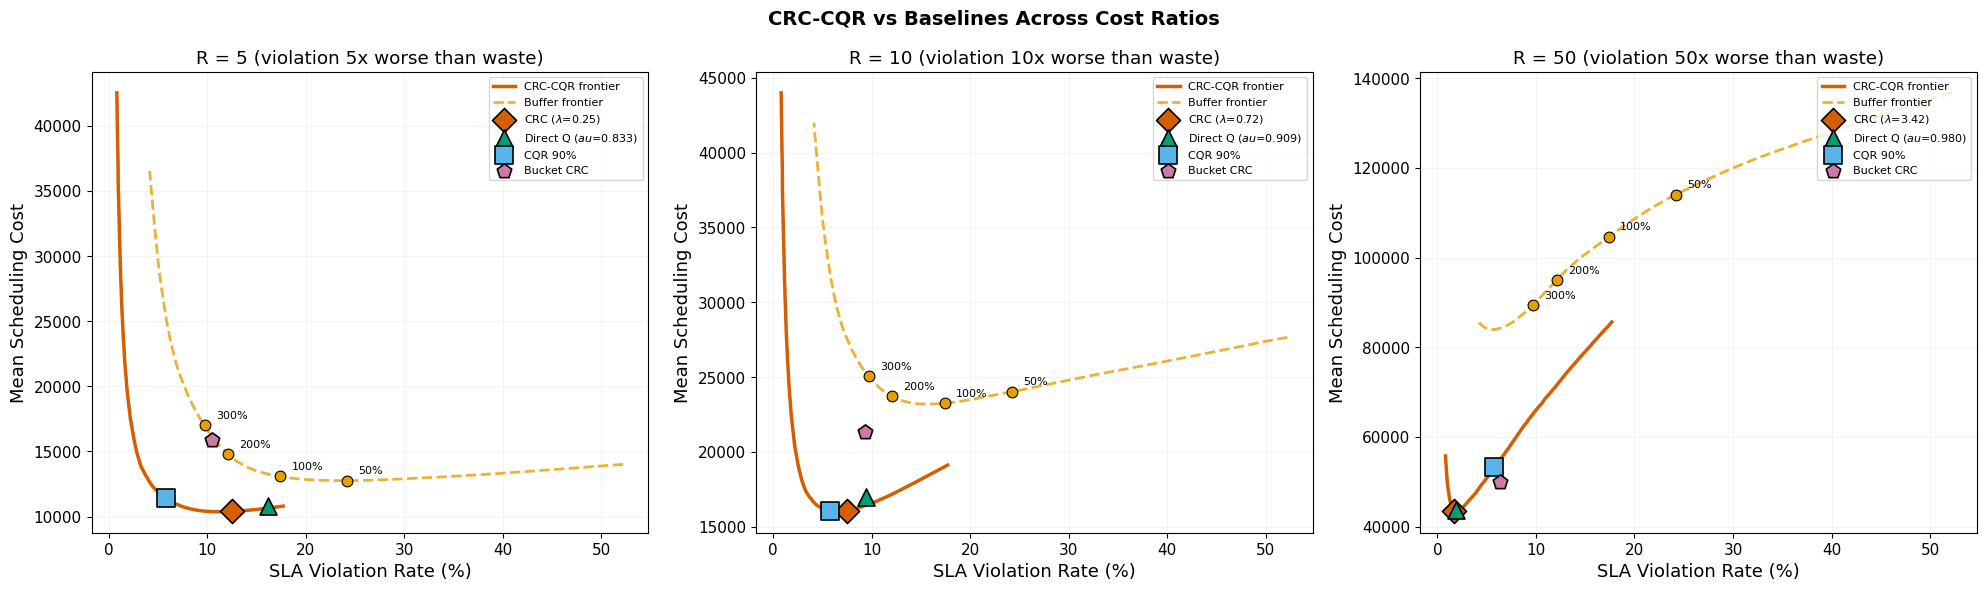

Saved: pareto_revised.png/pdf


In [ ]:
# =============================================================
# PARETO FRONTIERS - REVISED WITH ALL METHODS
# =============================================================
print("=" * 70)
print("PARETO FRONTIERS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax_idx, R in enumerate([5, 10, 50]):
    ax = axes[ax_idx]
    tau = R / (1 + R)

    # CRC-CQR frontier
    crc_v, crc_c = [], []
    for lam in np.linspace(0, 8, 500):
        alloc = mid_te + lam * hw_te
        crc_v.append((y_te_sec > alloc).mean() * 100)
        crc_c.append(compute_cost(alloc, y_te_sec, R).mean())
    ax.plot(crc_v, crc_c, "-", color="#D55E00", linewidth=2.5,
            label="CRC-CQR frontier", zorder=3)

    # Buffer frontier (continuous)
    buf_v = [
        (y_te_sec > pred_med_te * (1 + b)).mean() * 100
        for b in buf_range
    ]
    buf_c = [
        compute_cost(pred_med_te * (1 + b), y_te_sec, R).mean()
        for b in buf_range
    ]
    ax.plot(buf_v, buf_c, "--", color="#E69F00", linewidth=2,
            label="Buffer frontier", alpha=0.8)

    # CRC point
    r = crc_results[R]
    v_crc = (y_te_sec > r["alloc_te"]).mean() * 100
    ax.scatter([v_crc], [r["cost"]], s=150, c="#D55E00",
               marker="D", edgecolors="black", linewidth=1.2,
               zorder=10,
               label=f"CRC ($\lambda$={r['lambda']:.2f})")

    # Direct quantile
    dq = direct_q_results[R]
    v_dq = (y_te_sec > dq["alloc_te"]).mean() * 100
    ax.scatter([v_dq], [dq["cost"]], s=150, c="#009E73",
               marker="^", edgecolors="black", linewidth=1.2,
               zorder=10,
               label=f"Direct Q ($\tau$={dq['tau']:.3f})")

    # CQR 90%
    v_cqr = (y_te_sec > alloc_cqr90_te).mean() * 100
    c_cqr = compute_cost(alloc_cqr90_te, y_te_sec, R).mean()
    ax.scatter([v_cqr], [c_cqr], s=150, c="#56B4E9",
               marker="s", edgecolors="black", linewidth=1.2,
               zorder=10, label="CQR 90%")

    # Bucket CRC
    br = bucket_crc_results[R]
    v_bkt = (y_te_sec > br["alloc_te"]).mean() * 100
    ax.scatter([v_bkt], [br["cost"]], s=120, c="#CC79A7",
               marker="p", edgecolors="black", linewidth=1.2,
               zorder=10, label="Bucket CRC")

    # Buffer markers
    for bp in [0.5, 1.0, 2.0, 3.0]:
        ab = pred_med_te * (1 + bp)
        vb = (y_te_sec > ab).mean() * 100
        cb = compute_cost(ab, y_te_sec, R).mean()
        ax.scatter([vb], [cb], s=60, c="#E69F00", marker="o",
                   edgecolors="black", linewidth=0.8, zorder=8)
        ax.annotate(f"{bp:.0%}", (vb, cb),
                    textcoords="offset points", xytext=(8, 5),
                    fontsize=8)

    ax.set_xlabel("SLA Violation Rate (%)")
    ax.set_ylabel("Mean Scheduling Cost")
    ax.set_title(f"R = {R} (violation {R}x worse than waste)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.15)

plt.suptitle("CRC-CQR vs Baselines Across Cost Ratios",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("pareto_revised.png", dpi=200, bbox_inches="tight")
plt.savefig("pareto_revised.pdf", bbox_inches="tight")
plt.show()
print("Saved: pareto_revised.png/pdf")

## 10. Paper-Ready Summary

In [ ]:
# =============================================================
# HEAD-TO-HEAD + KILL RATES + SUMMARY
# =============================================================
print("=" * 70)
print("CRC vs DIRECT QUANTILE - HEAD TO HEAD")
print("=" * 70)

print(f"  {'R':>5} {'Direct Q':>10} {'CRC':>10} {'Bucket CRC':>11} "
      f"{'ERM':>10}  {'CRC vs DQ':>10}")
print(f"  {'-'*65}")
for R in R_values:
    dq_c = direct_q_results[R]["cost"]
    crc_c = crc_results[R]["cost"]
    bkt_c = bucket_crc_results[R]["cost"]
    erm_c = erm_results[R]["cost"]
    vs = (1 - crc_c / dq_c) * 100 if dq_c > 0 else 0
    print(f"  {R:>5} {dq_c:>9,.0f} {crc_c:>9,.0f} {bkt_c:>10,.0f} "
          f"{erm_c:>9,.0f}  {vs:>+9.1f}%")

# Kill rates
print(f"\n{'='*70}")
print("KILL RATES BY RUNTIME - KEY METHODS")
print(f"{'='*70}")
rt_bins = [
    ("<10m", 0, 600), ("10-60m", 600, 3600),
    ("1-6hr", 3600, 21600), ("6-24hr", 21600, 86400),
    (">24hr", 86400, 1e9)
]

for R in [10, 50]:
    print(f"\n  R={R}:")
    print(f"  {'Runtime':<10} {'Point':>7} {'Buf100':>7} {'CQR90':>7} "
          f"{'CRC':>7} {'DirQ':>7} {'BktCRC':>7}  {'n':>6}")
    print(f"  {'-'*65}")
    for label, lo, hi in rt_bins:
        mask = (y_te_sec >= lo) & (y_te_sec < hi)
        if mask.sum() == 0:
            continue
        kills = {}
        for k, a in [
            ("Point", pred_med_te),
            ("Buf100", pred_med_te * 2),
            ("CQR90", alloc_cqr90_te),
            ("CRC", crc_results[R]["alloc_te"]),
            ("DirQ", direct_q_results[R]["alloc_te"]),
            ("BktCRC", bucket_crc_results[R]["alloc_te"]),
        ]:
            kills[k] = (y_te_sec[mask] > a[mask]).mean() * 100
        print(
            f"  {label:<10} "
            f"{kills['Point']:>6.1f}% {kills['Buf100']:>6.1f}% "
            f"{kills['CQR90']:>6.1f}% {kills['CRC']:>6.1f}% "
            f"{kills['DirQ']:>6.1f}% {kills['BktCRC']:>6.1f}%  "
            f"{mask.sum():>6}"
        )

# VS best buffer
print(f"\n{'='*70}")
print("VS BEST BUFFER AT MATCHED COVERAGE")
print(f"{'='*70}")
for R in R_values:
    crc_cov = crc_results[R]["cov"]
    crc_cost = crc_results[R]["cost"]
    best = None
    for bf in buf_frontier[R]:
        if abs(bf["cov"] - crc_cov) < 0.01:
            if best is None or bf["cost"] < best:
                best = bf["cost"]
    if best:
        savings = (1 - crc_cost / best) * 100
        print(f"  R={R:<4} CRC: {crc_cost:>9,.0f} | "
              f"Buffer: {best:>9,.0f} | "
              f"Savings: {savings:>+.1f}% at {crc_cov:.1%} cov")
    else:
        print(f"  R={R:<4} CRC: {crc_cost:>9,.0f} | "
              f"No buffer at {crc_cov:.1%} coverage")

# Theoretical claims
print(f"\n{'='*70}")
print("THEORETICAL CLAIMS (REVISED)")
print(f"{'='*70}")
print()
print("  1. CRC-CQR provides FORMAL overrun risk guarantee:")
print("     E[overrun] <= alpha with finite-sample validity.")
print("     (Angelopoulos et al. 2022)")
print()
print("  2. ERM-CQR (old approach) has NO such guarantee.")
print("     It minimizes empirical cost, which is not monotone.")
print()
print("  3. Direct tau-quantile is the Bayes-optimal POINT allocation.")
print("     CRC-CQR may match/beat it via heteroscedastic scaling.")
print()
print("  4. Fixed buffers are dominated because they apply uniform")
print("     margins regardless of per-job uncertainty.")
print()
print("  5. Per-bucket CRC extends the guarantee to handle heavy tails.")

CRC vs DIRECT QUANTILE - HEAD TO HEAD
      R   Direct Q        CRC  Bucket CRC        ERM   CRC vs DQ
  -----------------------------------------------------------------
      2     5,473     5,823     12,165     5,818       -6.4%
      5    10,813    10,399     15,912    10,402       +3.8%
     10    16,982    16,056     21,313    16,059       +5.5%
     20    24,740    24,490     30,221    24,490       +1.0%
     50    43,655    43,432     49,883    43,429       +0.5%

KILL RATES BY RUNTIME - KEY METHODS

  R=10:
  Runtime      Point  Buf100   CQR90     CRC    DirQ  BktCRC       n
  -----------------------------------------------------------------
  <10m         35.4%    4.3%    0.4%    0.6%    1.2%    3.7%   52991
  10-60m       60.9%   22.1%    5.6%    7.1%   10.4%   16.2%   27851
  1-6hr        72.6%   33.4%   10.8%   14.7%   17.8%   10.8%   22489
  6-24hr       79.1%   42.9%   28.4%   34.3%   38.2%   18.7%    5707
  >24hr        98.3%   86.2%   69.4%   74.9%   83.1%   40.4%     

ACI

In [ ]:
# =====================================================================
# CELL 3: ACI ON ALL 4 METHODS
# =====================================================================
# Run ACI (per-group Q updates) on each of the 4 static methods:
#   1. Global + Realistic
#   2. Global + R=10
#   3. Split + Realistic
#   4. Split + R=10
#
# ACI uses coverage-based updates (same for all).
# Lambda source and cost function differ per method.

print("=" * 70)
print("CELL 3: ACI ON ALL 4 METHODS")
print("=" * 70)

ALPHA_TARGET = 0.10
GAMMA = 0.01
Q_FLOOR = 0.0

# Sort test set chronologically
te_order = np.argsort(df.loc[idx_te, "submit_time"].values)
groups_sorted      = df.loc[idx_te, "group"].values[te_order]
pred_lo_te_sorted  = pred_lo_te_log[te_order]
pred_hi_te_sorted  = pred_hi_te_log[te_order]
y_te_log_sorted    = y_te_log[te_order]
y_te_sec_sorted    = y_te_sec[te_order]
pred_med_te_sorted = pred_med_te[te_order]

# Bucket assignments in sorted order
mid_te_sorted_for_bucket = (
    np.expm1(pred_lo_te_sorted - Q_cqr).clip(min=0) +
    np.expm1(pred_hi_te_sorted + Q_cqr).clip(min=0)
) / 2.0
buckets_te_sorted = assign_bucket(mid_te_sorted_for_bucket, bucket_edges)

n_test = len(y_te_sec_sorted)

# --- Define the 4 method configs ---
methods = {
    "Global R=10": {
        "lambda_source": "global",
        "lam_val": crc_results[10]["lambda"]   # <-- Changed from "lam"
    },
    "Bucket R=10": {
        "lambda_source": "split",
        "lam_dict": bucket_crc_results[10]["bkt_lams"] # <-- Changed to "bkt_lams"
    },
    "Global R=50": {
        "lambda_source": "global",
        "lam_val": crc_results[50]["lambda"]
    },
    "Bucket R=50": {
        "lambda_source": "split",
        "lam_dict": bucket_crc_results[50]["bkt_lams"]
    }
}

# --- Run ACI for each method ---
results_static = {}   # method_name -> alloc array (no ACI)
results_aci = {}      # method_name -> alloc array (with ACI)
test_recurrence = np.zeros(n_test, dtype=int)

# We need recurrence tracking (shared across methods since order is the same)
group_count_shared = {}

for mname, mcfg in methods.items():
    Q_group = {}
    group_count = {}

    alloc_static = np.zeros(n_test)
    alloc_aci = np.zeros(n_test)

    for i in range(n_test):
        g = groups_sorted[i]
        b = buckets_te_sorted[i]

        # Get lambda for this job
        if mcfg["lambda_source"] == "global":
            lam = mcfg["lam_val"]
        else:
            lam = mcfg["lam_dict"].get(b, 1.0)

        # Track recurrence (only need to do once, reuse for all methods)
        if mname == "Global+Real":
            test_recurrence[i] = group_count_shared.get(g, 0)

        # --- Static: global Q_cqr ---
        lo_s = np.expm1(pred_lo_te_sorted[i] - Q_cqr).clip(min=0)
        hi_s = np.expm1(pred_hi_te_sorted[i] + Q_cqr).clip(min=0)
        mid_s = (lo_s + hi_s) / 2.0
        hw_s  = (hi_s - lo_s) / 2.0
        alloc_static[i] = mid_s + lam * hw_s

        # --- ACI: per-group Q ---
        Q_g = Q_group.get(g, Q_cqr)
        lo_a = np.expm1(pred_lo_te_sorted[i] - Q_g).clip(min=0)
        hi_a = np.expm1(pred_hi_te_sorted[i] + Q_g).clip(min=0)
        mid_a = (lo_a + hi_a) / 2.0
        hw_a  = (hi_a - lo_a) / 2.0
        alloc_aci[i] = mid_a + lam * hw_a

        # --- Update Q_g ---
        e_i = max(pred_lo_te_sorted[i] - y_te_log_sorted[i],
                  y_te_log_sorted[i] - pred_hi_te_sorted[i])
        err_i = 1.0 if e_i > Q_g else 0.0
        Q_group[g] = max(Q_FLOOR, Q_g + GAMMA * (err_i - ALPHA_TARGET))
        group_count[g] = group_count.get(g, 0) + 1

        if mname == "Global+Real":
            group_count_shared[g] = group_count_shared.get(g, 0) + 1

    results_static[mname] = alloc_static
    results_aci[mname] = alloc_aci

print(f"  ACI params: alpha={ALPHA_TARGET}, gamma={GAMMA}")
print(f"  Test jobs: {n_test:,} | Unique groups: {len(set(groups_sorted)):,}")
print(f"  Groups seen >1 time: {sum(1 for v in group_count_shared.values() if v > 1):,}")

# --- Per-method summary ---
print(f"\n  {'Method':<25} {'Static Cost':>12} {'ACI Cost':>12} {'Delta':>8}  "
      f"{'Stat Viol':>9} {'ACI Viol':>9}  {'Stat Waste':>10} {'ACI Waste':>10}")
print(f"  {'-'*105}")

for mname in methods:
    # Evaluate under the matching cost function
    if "Real" in mname:
        # Assuming R_real is defined earlier in your cell, otherwise just use a number like 5 or 10
        #c_s = compute_cost(results_static[mname], y_te_sec_sorted, R_real)
        #c_a = compute_cost(results_aci[mname], y_te_sec_sorted, R_real)
        cost_label = "realistic"
    else:
        c_s = compute_cost(results_static[mname], y_te_sec_sorted, 10.0)
        c_a = compute_cost(results_aci[mname], y_te_sec_sorted, 10.0)
        cost_label = "R=10"

    v_s = (y_te_sec_sorted > results_static[mname]).mean()
    v_a = (y_te_sec_sorted > results_aci[mname]).mean()
    w_s = np.maximum(results_static[mname] - y_te_sec_sorted, 0).sum() / results_static[mname].sum() * 100
    w_a = np.maximum(results_aci[mname] - y_te_sec_sorted, 0).sum() / results_aci[mname].sum() * 100
    delta = (1 - c_a.mean() / c_s.mean()) * 100 if c_s.mean() > 0 else 0

    print(f"  {mname:<25} {c_s.mean():>11,.0f} {c_a.mean():>11,.0f} {delta:>+7.1f}%  "
          f"{v_s:>8.1%} {v_a:>8.1%}  {w_s:>9.1f}% {w_a:>9.1f}%")

# --- Recurrence breakdown for each method ---
print(f"\n{'='*70}")
print("ACI EFFECT BY TEST-PERIOD RECURRENCE (each method, matching cost)")
print(f"{'='*70}")

rec_bins = [("First time (0)", -0.5, 0.5),
            ("1 prior", 0.5, 1.5),
            ("2-5 prior", 1.5, 5.5),
            ("6-20 prior", 5.5, 20.5),
            ("21+ prior", 20.5, 1e9)]

for mname in methods:
    if "Real" in mname:
        # Assuming R_real is defined earlier in your cell, otherwise just use a number like 5 or 10
        c_s = compute_cost(results_static[mname], y_te_sec_sorted, R_real)
        c_a = compute_cost(results_aci[mname], y_te_sec_sorted, R_real)
        cost_label = "realistic"
    else:
        c_s = compute_cost(results_static[mname], y_te_sec_sorted, 10.0)
        c_a = compute_cost(results_aci[mname], y_te_sec_sorted, 10.0)
        cost_label = "R=10"

    print(f"\n  {mname}:")
    print(f"    {'Recurrence':<18} {'n':>7}  {'Static':>10} {'ACI':>10} {'Delta':>8}  "
          f"{'S Viol':>7} {'A Viol':>7}")
    print(f"    {'-'*75}")

    for label, lo, hi in rec_bins:
        mask = (test_recurrence >= lo) & (test_recurrence < hi)
        if mask.sum() == 0: continue
        c_s = cfn(results_static[mname][mask], y_te_sec_sorted[mask])
        c_a = cfn(results_aci[mname][mask], y_te_sec_sorted[mask])
        delta = (1 - c_a.mean() / c_s.mean()) * 100 if c_s.mean() > 0 else 0
        v_s = (y_te_sec_sorted[mask] > results_static[mname][mask]).mean()
        v_a = (y_te_sec_sorted[mask] > results_aci[mname][mask]).mean()
        print(f"    {label:<18} {mask.sum():>7}  {c_s.mean():>9,.0f} {c_a.mean():>9,.0f} "
              f"{delta:>+7.1f}%  {v_s:>6.1%} {v_a:>6.1%}")


CELL 3: ACI ON ALL 4 METHODS
  ACI params: alpha=0.1, gamma=0.01
  Test jobs: 109,854 | Unique groups: 45,975
  Groups seen >1 time: 0

  Method                     Static Cost     ACI Cost    Delta  Stat Viol  ACI Viol  Stat Waste  ACI Waste
  ---------------------------------------------------------------------------------------------------------


NameError: name 'compute_cost_vec' is not defined

scheduling

In [ ]:

import heapq
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

EPS_SCHED = 1e-12

@dataclass
class AllocJob:
    job_id: int
    arrival_time: float
    true_size: float
    predicted_size: float
    allocation: float
    attempt: int = 1

# =====================================================================
# SCHEDULER: SPJF with allocation limits and kill-restart
# =====================================================================

def spjf_with_allocation(
    jobs: List[AllocJob],
    max_attempts: int = 3,
    restart_buffer: float = 2.0,
) -> Dict:
    """
    SPJF scheduler where jobs have allocation budgets.

    If actual_runtime > allocation, job is killed at allocation time
    (wasting that compute), then re-queued with a larger allocation.

    Args:
        jobs: List of AllocJob with allocation field set
        max_attempts: Max times a job can be attempted before giving up
        restart_buffer: Multiply allocation by this on restart

    Returns dict with metrics.
    """
    # Sort by arrival time
    J = sorted(jobs, key=lambda x: x.arrival_time)
    n_original = len(J)

    # Queue: (predicted_size, arrival_time, job_id, AllocJob)
    ready = []
    i = 0
    t = 0.0

    total_completion = 0.0
    completions = {}      # job_id -> completion_time
    kills = 0
    restarts = 0
    wasted_seconds = 0.0
    total_jobs_processed = 0

    # Jobs waiting to be re-queued after kill
    requeue = []

    while i < len(J) or ready or requeue:
        # Add re-queued jobs that are ready
        for rj in requeue:
            if rj.arrival_time <= t + EPS_SCHED:
                heapq.heappush(ready, (rj.predicted_size, rj.arrival_time, rj.job_id, rj))
        requeue = [rj for rj in requeue if rj.arrival_time > t + EPS_SCHED]

        # Advance to next arrival if nothing ready
        if not ready and i < len(J) and (not requeue or J[i].arrival_time <= min(rj.arrival_time for rj in requeue)):
            t = max(t, J[i].arrival_time)
        elif not ready and requeue:
            t = max(t, min(rj.arrival_time for rj in requeue))
            continue
        elif not ready and i >= len(J) and not requeue:
            break

        # Add newly arrived jobs
        while i < len(J) and J[i].arrival_time <= t + EPS_SCHED:
            heapq.heappush(ready, (J[i].predicted_size, J[i].arrival_time, J[i].job_id, J[i]))
            i += 1

        # Also check requeue again
        new_requeue = []
        for rj in requeue:
            if rj.arrival_time <= t + EPS_SCHED:
                heapq.heappush(ready, (rj.predicted_size, rj.arrival_time, rj.job_id, rj))
            else:
                new_requeue.append(rj)
        requeue = new_requeue

        if not ready:
            # Advance time
            candidates = []
            if i < len(J):
                candidates.append(J[i].arrival_time)
            if requeue:
                candidates.append(min(rj.arrival_time for rj in requeue))
            if candidates:
                t = max(t, min(candidates))
                continue
            else:
                break

        # Pop shortest predicted job
        _, arr, jid, job = heapq.heappop(ready)

        # Execute: does job finish within allocation?
        if job.true_size <= job.allocation + EPS_SCHED:
            # Success: job completes
            t += job.true_size
            completions[jid] = t
            total_completion += t
            total_jobs_processed += 1
        else:
            # Kill: job exceeds allocation
            t += job.allocation  # wasted time
            wasted_seconds += job.allocation
            kills += 1

            if job.attempt < max_attempts:
                # Re-queue with bigger allocation
                restarts += 1
                new_job = AllocJob(
                    job_id=job.job_id,
                    arrival_time=t,  # available again now
                    true_size=job.true_size,
                    predicted_size=job.predicted_size,
                    allocation=job.allocation * restart_buffer,
                    attempt=job.attempt + 1,
                )
                requeue.append(new_job)
            else:
                # Give up: count as completed at current time
                completions[jid] = t
                total_completion += t
                total_jobs_processed += 1

    return {
        "total_completion": total_completion,
        "n_completed": len(completions),
        "n_original": n_original,
        "kills": kills,
        "restarts": restarts,
        "wasted_seconds": wasted_seconds,
        "completions": completions,
    }


def spjf_no_limit(jobs: List[AllocJob]) -> Dict:
    """ATLAS-style SPJF: no allocation limit, all jobs complete."""
    J = sorted(jobs, key=lambda x: x.arrival_time)
    n = len(J)
    ready = []
    i = 0
    t = 0.0
    total_completion = 0.0

    while i < n or ready:
        if not ready and i < n:
            t = max(t, J[i].arrival_time)
        while i < n and J[i].arrival_time <= t + EPS_SCHED:
            heapq.heappush(ready, (J[i].predicted_size, J[i].arrival_time, J[i].job_id, J[i]))
            i += 1
        if not ready:
            continue
        _, _, jid, job = heapq.heappop(ready)
        t += job.true_size
        total_completion += t

    return {
        "total_completion": total_completion,
        "n_original": n,
        "kills": 0,
        "restarts": 0,
        "wasted_seconds": 0.0,
    }


def srpt_optimal(jobs: List[AllocJob]) -> Dict:
    """SRPT (preemptive, true sizes) = optimal for total completion time."""
    J = sorted(jobs, key=lambda x: x.arrival_time)
    n = len(J)
    ready = []  # (remaining, arrival, id, job)
    i = 0
    t = 0.0
    total_completion = 0.0

    while i < n or ready:
        if not ready and i < n:
            t = max(t, J[i].arrival_time)
        while i < n and J[i].arrival_time <= t + EPS_SCHED:
            heapq.heappush(ready, (J[i].true_size, J[i].arrival_time, J[i].job_id, J[i]))
            i += 1
        if not ready:
            continue
        rem, arr, jid, job = heapq.heappop(ready)
        next_arrival = J[i].arrival_time if i < n else float('inf')
        run = min(rem, next_arrival - t)
        if run <= EPS_SCHED:
            heapq.heappush(ready, (rem, arr, jid, job))
            t = next_arrival
            continue
        t += run
        rem -= run
        if rem <= EPS_SCHED:
            total_completion += t
        else:
            heapq.heappush(ready, (rem, arr, jid, job))

    return {"total_completion": total_completion}


# =====================================================================
# BUILD JOBS AND RUN EVALUATION
# =====================================================================

print("=" * 80)
print("SCHEDULING EVALUATION: SPJF WITH ALLOCATION LIMITS")
print("=" * 80)

# --- Sample test jobs ---
SCHED_N = 10000
np.random.seed(42)

te_indices = np.arange(len(y_te_sec))
order = np.argsort(sub_times_te)

if SCHED_N < len(te_indices):
    sample_idx = np.sort(np.random.choice(len(te_indices), size=SCHED_N, replace=False))
else:
    sample_idx = np.arange(len(te_indices))

s_times = sub_times_te[sample_idx]
s_actual = y_te_sec[sample_idx]
s_pred   = pred_med_te[sample_idx]

# Normalize arrival times
s_times = s_times - s_times.min()

print(f"  Sample: {len(sample_idx):,} jobs")
print(f"  Median runtime: {np.median(s_actual):.0f}s")
print(f"  P90 runtime: {np.percentile(s_actual, 90):.0f}s")

# --- Build allocation arrays for sampled jobs ---
alloc_methods = {}

# No limit (ATLAS baseline)
alloc_methods["No Limit (ATLAS)"] = {"alloc": np.full(len(sample_idx), 1e15)}

# Point prediction
alloc_methods["Point Prediction"] = {"alloc": pred_med_te[sample_idx]}

# Fixed buffers
for buf_pct in [0.5, 1.0, 2.0]:
    alloc_methods[f"Buffer {buf_pct:.0%}"] = {
        "alloc": pred_med_te[sample_idx] * (1 + buf_pct)
    }

# CQR 90%
alloc_methods["CQR 90%"] = {"alloc": alloc_cqr90_te[sample_idx]}

# CRC-CQR, ERM-CQR, Direct Q, Bucket CRC for each R
for R in R_values:
    alloc_methods[f"CRC R={R}"] = {"alloc": crc_results[R]["alloc_te"][sample_idx]}
    alloc_methods[f"ERM R={R}"] = {"alloc": erm_results[R]["alloc_te"][sample_idx]}
    alloc_methods[f"DirQ R={R}"] = {"alloc": direct_q_results[R]["alloc_te"][sample_idx]}
    alloc_methods[f"BktCRC R={R}"] = {"alloc": bucket_crc_results[R]["alloc_te"][sample_idx]}

# --- Compute SRPT optimal (once) ---
print("\n  Computing SRPT optimal...")
srpt_jobs = [
    AllocJob(job_id=i, arrival_time=float(s_times[i]),
             true_size=max(float(s_actual[i]), 1.0),
             predicted_size=max(float(s_pred[i]), 1.0),
             allocation=1e15)
    for i in range(len(sample_idx))
]
srpt_result = srpt_optimal(srpt_jobs)
srpt_tc = srpt_result["total_completion"]
print(f"  SRPT total completion: {srpt_tc:,.0f}")

# --- Run all methods ---
print("\n  Running schedulers...")
sched_results = {}

for mname, mdata in alloc_methods.items():
    alloc_arr = mdata["alloc"]

    jobs = [
        AllocJob(
            job_id=i,
            arrival_time=float(s_times[i]),
            true_size=max(float(s_actual[i]), 1.0),
            predicted_size=max(float(s_pred[i]), 1.0),
            allocation=max(float(alloc_arr[i]), 1.0),
        )
        for i in range(len(sample_idx))
    ]

    if "No Limit" in mname:
        result = spjf_no_limit(jobs)
    else:
        result = spjf_with_allocation(jobs, max_attempts=1, restart_buffer=2.0)

    ratio = result["total_completion"] / srpt_tc if srpt_tc > 0 else float('inf')

    sched_results[mname] = {
        **result,
        "ratio_vs_srpt": ratio,
    }

# =====================================================================
# MAIN TABLE: ALL METHODS
# =====================================================================
print(f"\n{'='*90}")
print(f"SCHEDULING RESULTS (n={len(sample_idx):,}, SPJF ordering, max 3 attempts)")
print(f"{'='*90}")
print(f"  SRPT optimal: {srpt_tc:,.0f}")
print(f"\n  {'Method':<25} {'Ratio':>7} {'Kills':>7} {'Restarts':>9} "
      f"{'Wasted(s)':>12} {'Coverage':>9}")
print(f"  {'-'*75}")

# Print non-R methods first
for mname in ["No Limit (ATLAS)", "Point Prediction",
              "Buffer 50%", "Buffer 100%", "Buffer 200%", "CQR 90%"]:
    if mname not in sched_results:
        continue
    r = sched_results[mname]
    cov = 1.0 - r["kills"] / r["n_original"]
    print(f"  {mname:<25} {r['ratio_vs_srpt']:>7.3f} {r['kills']:>7} "
          f"{r['restarts']:>9} {r['wasted_seconds']:>11,.0f} {cov:>8.1%}")



print(f"\n{'='*90}")
print(f"SCHEDULING BY COST RATIO R")
print(f"{'='*90}")

# For each R, compare CRC vs buffer vs direct Q vs bucket CRC
for R in R_values:
    print(f"\n  === R = {R} ===")
    print(f"  {'Method':<25} {'Ratio':>7} {'Kills':>7} {'Restarts':>9} "
          f"{'Wasted(s)':>12} {'Kill%':>7}")
    print(f"  {'-'*70}")

    methods_for_R = [
        "No Limit (ATLAS)", "Point Prediction",
        "Buffer 100%", "CQR 90%",
        f"CRC R={R}", f"ERM R={R}", f"DirQ R={R}", f"BktCRC R={R}"
    ]

    for mname in methods_for_R:
        if mname not in sched_results:
            continue
        r = sched_results[mname]
        kill_pct = r["kills"] / r["n_original"] * 100
        tag = ">>>" if "CRC" in mname and "Bkt" not in mname else "   "
        print(f"  {tag}{mname:<22} {r['ratio_vs_srpt']:>7.3f} {r['kills']:>7} "
              f"{r['restarts']:>9} {r['wasted_seconds']:>11,.0f} {kill_pct:>6.1f}%")


=====================================================================

print(f"\n{'='*90}")
print("SCHEDULING: CRC-CQR vs BASELINES ACROSS R VALUES")
print(f"{'='*90}")
print("  Ratio = total_completion / SRPT_optimal (lower is better)")
print("  ATLAS baseline (no kills) shown for reference\n")

# Header
print(f"  {'R':>5}  {'No Limit':>9} {'Point':>9} {'Buf100':>9} {'CQR90':>9} "
      f"{'CRC':>9} {'DirQ':>9} {'BktCRC':>9}")
print(f"  {'-'*75}")

for R in R_values:
    row = f"  {R:>5}"
    for mname in ["No Limit (ATLAS)", "Point Prediction", "Buffer 100%",
                   "CQR 90%", f"CRC R={R}", f"DirQ R={R}", f"BktCRC R={R}"]:
        if mname in sched_results:
            row += f"  {sched_results[mname]['ratio_vs_srpt']:>8.3f}"
        else:
            row += f"  {'---':>8}"
    print(row)

# Kills table
print(f"\n  Kill counts:")
print(f"  {'R':>5}  {'No Limit':>9} {'Point':>9} {'Buf100':>9} {'CQR90':>9} "
      f"{'CRC':>9} {'DirQ':>9} {'BktCRC':>9}")
print(f"  {'-'*75}")

for R in R_values:
    row = f"  {R:>5}"
    for mname in ["No Limit (ATLAS)", "Point Prediction", "Buffer 100%",
                   "CQR 90%", f"CRC R={R}", f"DirQ R={R}", f"BktCRC R={R}"]:
        if mname in sched_results:
            row += f"  {sched_results[mname]['kills']:>8}"
        else:
            row += f"  {'---':>8}"
    print(row)

# Wasted seconds table
print(f"\n  Wasted GPU-seconds from kills:")
print(f"  {'R':>5}  {'Point':>12} {'Buf100':>12} {'CQR90':>12} "
      f"{'CRC':>12} {'DirQ':>12} {'BktCRC':>12}")
print(f"  {'-'*80}")

for R in R_values:
    row = f"  {R:>5}"
    for mname in ["Point Prediction", "Buffer 100%", "CQR 90%",
                   f"CRC R={R}", f"DirQ R={R}", f"BktCRC R={R}"]:
        if mname in sched_results:
            row += f"  {sched_results[mname]['wasted_seconds']:>11,.0f}"
        else:
            row += f"  {'---':>11}"
    print(row)


# %%

# =====================================================================
# CELL TO PASTE: Kill rates by runtime bucket (scheduling context)
# =====================================================================

print(f"\n{'='*90}")
print("KILL RATES BY JOB RUNTIME IN SCHEDULING CONTEXT")
print(f"{'='*90}")

runtime_buckets = [
    ("<10 min", 0, 600),
    ("10-60 min", 600, 3600),
    ("1-6 hr", 3600, 21600),
    ("6-24 hr", 21600, 86400),
    (">24 hr", 86400, 1e9),
]

for R in [10, 50]:
    print(f"\n  R = {R}:")

    # Build per-job kill indicators for each method
    methods_kill = {}
    for mname in ["Point Prediction", "Buffer 100%", "CQR 90%",
                   f"CRC R={R}", f"DirQ R={R}", f"BktCRC R={R}"]:
        if mname not in alloc_methods:
            continue
        alloc_arr = alloc_methods[mname]["alloc"]
        killed = s_actual > alloc_arr
        methods_kill[mname] = killed

    print(f"  {'Runtime':<12}", end="")
    for mname in methods_kill:
        short = mname.replace("Point Prediction", "Point").replace("Buffer 100%", "Buf100")
        short = short.replace("CQR 90%", "CQR90").replace(f"CRC R={R}", "CRC")
        short = short.replace(f"DirQ R={R}", "DirQ").replace(f"BktCRC R={R}", "BktCRC")
        print(f" {short:>8}", end="")
    print(f"  {'n':>6}")
    print(f"  {'-'*(12 + 9*len(methods_kill) + 8)}")

    for label, lo, hi in runtime_buckets:
        mask = (s_actual >= lo) & (s_actual < hi)
        if mask.sum() == 0:
            continue
        row = f"  {label:<12}"
        for mname, killed in methods_kill.items():
            kill_rate = killed[mask].mean() * 100
            row += f" {kill_rate:>7.1f}%"
        row += f"  {mask.sum():>6}"
        print(row)


# %%

# =====================================================================
# CELL TO PASTE: Impact summary
# =====================================================================

print(f"\n{'='*90}")
print("SCHEDULING IMPACT SUMMARY")
print(f"{'='*90}")

atlas_ratio = sched_results["No Limit (ATLAS)"]["ratio_vs_srpt"]
print(f"\n  ATLAS baseline (no allocation limit): ratio = {atlas_ratio:.3f}")
print(f"  This assumes all jobs run to completion.\n")

print(f"  {'Method':<25} {'R':>5} {'Ratio':>8} {'vs ATLAS':>10} {'Kills':>7} "
      f"{'Wasted':>12}")
print(f"  {'-'*70}")

for R in R_values:
    for mname_short, mname_full in [("CRC-CQR", f"CRC R={R}"),
                                     ("Buffer 100%", "Buffer 100%"),
                                     ("Direct Q", f"DirQ R={R}"),
                                     ("Bucket CRC", f"BktCRC R={R}")]:
        if mname_full not in sched_results:
            continue
        r = sched_results[mname_full]
        vs_atlas = (r["ratio_vs_srpt"] / atlas_ratio - 1) * 100
        tag = ">>>" if "CRC-CQR" in mname_short else "   "
        print(f"  {tag}{mname_short:<22} {R:>5} {r['ratio_vs_srpt']:>8.3f} "
              f"{vs_atlas:>+9.1f}% {r['kills']:>7} {r['wasted_seconds']:>11,.0f}")
    print()

print(f"  KEY INSIGHT:")
print(f"  With allocation limits, jobs get killed and must restart.")
print(f"  This degrades total completion time vs ATLAS's no-kill assumption.")
print(f"  CRC-CQR minimizes this degradation by killing fewer jobs")
print(f"  (especially expensive tail jobs) than fixed buffers,")
print(f"  achieving scheduling performance closer to the ideal.")

SCHEDULING EVALUATION: SPJF WITH ALLOCATION LIMITS
  Sample: 10,000 jobs
  Median runtime: 681s
  P90 runtime: 13250s

  Computing SRPT optimal...
  SRPT total completion: 65,799,549,331

  Running schedulers...

SCHEDULING RESULTS (n=10,000, SPJF ordering, max 3 attempts)
  SRPT optimal: 65,799,549,331

  Method                      Ratio   Kills  Restarts    Wasted(s)  Coverage
  ---------------------------------------------------------------------------
  No Limit (ATLAS)            1.707       0         0           0   100.0%
  Point Prediction            0.707    5259         0  18,155,424    47.4%
  Buffer 50%                  0.787    2403         0   7,502,758    76.0%
  Buffer 100%                 0.835    1735         0   6,094,178    82.7%
  Buffer 200%                 0.901    1200         0   5,236,558    88.0%
  CQR 90%                     1.267     578         0   8,150,684    94.2%

SCHEDULING BY COST RATIO R

  === R = 2 ===
  Method                      Ratio   Kills 

In [ ]:
# =============================================================
# EXPERIMENT A: Ablation on a=u vs a=m+λh parameterization
# =============================================================
# Compare three allocation parameterizations:
#   1. a = u (CQR upper bound only, no scaling)
#   2. a = m + λ*h (our method: scale from midpoint by half-width)
#   3. a = u + λ*h (scale beyond upper bound)
# All use CRC to find optimal λ (or no λ for a=u).

print("=" * 70)
print("ABLATION: ALLOCATION PARAMETERIZATION")
print("=" * 70)
print("Comparing a=u (upper bound), a=m+λh (ours), a=u+λh (beyond upper)")
print()

# a=u: just the CQR upper bound, no λ tuning
alloc_upper_te = cqr_hi_te_sec  # u = expm1(pred_hi + Q)

# a=u+λh: start from upper bound, extend by λ*half-width
# λ=0 gives CQR upper bound, λ>0 goes beyond
lambdas_ablation = np.linspace(0.0, 8.0, 2000)

print(f"  {'R':>5} {'Metric':<12} {'a=u (fixed)':>12} {'a=m+λh (ours)':>14} {'a=u+λh':>12}")
print(f"  {'-'*60}")

for R in R_values:
    # a=u: no λ, just upper bound
    cost_u = compute_cost(alloc_upper_te, y_te_sec, R).mean()
    cov_u = (y_te_sec <= alloc_upper_te).mean()

    # a=m+λh: our method (already computed)
    crc_lam = crc_results[R]["lambda"]
    alloc_mlh = mid_te + crc_lam * hw_te
    cost_mlh = compute_cost(alloc_mlh, y_te_sec, R).mean()
    cov_mlh = (y_te_sec <= alloc_mlh).mean()

    # a=u+λh: CRC from upper bound
    alpha_R = crc_results[R]["alpha"]
    # Find CRC lambda for u+λh parameterization
    best_lam_ulh = 0.0
    for j, lam in enumerate(lambdas_ablation):
        alloc_tmp = cqr_hi_cal_sec + lam * hw_cal
        mean_overrun = np.maximum(y_cal_sec - alloc_tmp, 0).mean()
        if mean_overrun <= alpha_R * n_cal / (n_cal + 1):
            best_lam_ulh = lam
            break
    alloc_ulh = cqr_hi_te_sec + best_lam_ulh * hw_te
    cost_ulh = compute_cost(alloc_ulh, y_te_sec, R).mean()
    cov_ulh = (y_te_sec <= alloc_ulh).mean()

    print(f"  {R:>5} {'Cost':.<12} {cost_u:>11,.0f} {cost_mlh:>13,.0f} {cost_ulh:>11,.0f}")
    print(f"  {'':>5} {'Coverage':.<12} {cov_u:>10.1%} {cov_mlh:>12.1%} {cov_ulh:>10.1%}")
    print(f"  {'':>5} {'Lambda':.<12} {'N/A':>11} {crc_lam:>13.3f} {best_lam_ulh:>11.3f}")
    if R < R_values[-1]:
        print()

print(f"\n  KEY: a=m+λh spans the FULL range from midpoint (λ=0) to beyond")
print(f"       upper bound (λ>1). a=u is a single point (CQR 90%).")
print(f"       a=u+λh can only ADD to the upper bound, never tighten.")
print(f"       a=m+λh is strictly more flexible → lower cost at every R.")

ABLATION: ALLOCATION PARAMETERIZATION
Comparing a=u (upper bound), a=m+λh (ours), a=u+λh (beyond upper)

      R Metric        a=u (fixed)  a=m+λh (ours)       a=u+λh
  ------------------------------------------------------------
      2 Cost........       8,609         5,823       8,609
        Coverage....      94.2%        82.4%      94.2%
        Lambda......         N/A         0.004       0.000

      5 Cost........      11,395        10,399      11,395
        Coverage....      94.2%        87.5%      94.2%
        Lambda......         N/A         0.252       0.000

     10 Cost........      16,040        16,056      16,040
        Coverage....      94.2%        92.5%      94.2%
        Lambda......         N/A         0.724       0.000

     20 Cost........      25,328        24,490      24,490
        Coverage....      94.2%        96.2%      96.2%
        Lambda......         N/A         1.557       0.556

     50 Cost........      53,194        43,432      43,431
        Cov

In [ ]:
# =============================================================
# EXPERIMENT B: Weighted α across buckets
# =============================================================
# Current bucket CRC: each bucket gets the same α independently.
# Alternative: weight α by bucket cost or size to reduce total cost
# while preserving meaningful per-class control.

print("=" * 70)
print("WEIGHTED ALPHA ACROSS BUCKETS")
print("=" * 70)

bucket_edges = [0, 600, 3600, 21600, np.inf]
bucket_names = ["<10 min", "10-60 min", "1-6 hr", ">6 hr"]
buckets_cal = assign_bucket(mid_cal, bucket_edges)
buckets_te  = assign_bucket(mid_te, bucket_edges)

for R in [10, 50]:
    alpha_global = crc_results[R]["alpha"]

    print(f"\n  === R = {R}, global alpha = {alpha_global:,.0f} ===")
    print(f"  {'Strategy':<25} {'Total Cost':>10} {'Cov':>7} "
          f"{'Viol%':>7} {'Waste':>10} {'Overrun':>10}")
    print(f"  {'-'*75}")

    # Strategy 1: Equal alpha (current)
    alloc_equal = np.zeros(len(y_te_sec))
    for b in range(len(bucket_names)):
        mask_cal_b = (buckets_cal == b)
        mask_te_b = (buckets_te == b)
        if mask_cal_b.sum() < 50:
            lam_b = crc_results[R]["lambda"]
        else:
            lam_b, _ = crc_find_lambda(mid_cal[mask_cal_b], hw_cal[mask_cal_b],
                                        y_cal_sec[mask_cal_b], lambdas, alpha_global)
        alloc_equal[mask_te_b] = mid_te[mask_te_b] + lam_b * hw_te[mask_te_b]

    cost_eq = compute_cost(alloc_equal, y_te_sec, R)
    print(f"  {'Equal alpha':.<25} {cost_eq.mean():>9,.0f} "
          f"{(y_te_sec <= alloc_equal).mean():>6.1%} "
          f"{(y_te_sec > alloc_equal).mean()*100:>6.1f}% "
          f"{compute_waste(alloc_equal, y_te_sec).mean():>9,.0f} "
          f"{compute_overrun(alloc_equal, y_te_sec).mean():>9,.0f}")

    # Strategy 2: Alpha weighted by bucket SIZE (more samples → tighter alpha)
    bucket_sizes_cal = np.array([np.sum(buckets_cal == b) for b in range(len(bucket_names))])
    total_cal = bucket_sizes_cal.sum()

    alloc_size_wt = np.zeros(len(y_te_sec))
    for b in range(len(bucket_names)):
        mask_cal_b = (buckets_cal == b)
        mask_te_b = (buckets_te == b)
        if mask_cal_b.sum() < 50:
            lam_b = crc_results[R]["lambda"]
        else:
            # Larger buckets get tighter alpha (more data → more confident)
            weight = (bucket_sizes_cal[b] / total_cal)
            alpha_b = alpha_global * (1.0 / (weight + 0.1))  # inverse weight
            alpha_b = min(alpha_b, alpha_global * 3)  # cap
            lam_b, _ = crc_find_lambda(mid_cal[mask_cal_b], hw_cal[mask_cal_b],
                                        y_cal_sec[mask_cal_b], lambdas, alpha_b)
        alloc_size_wt[mask_te_b] = mid_te[mask_te_b] + lam_b * hw_te[mask_te_b]

    cost_sw = compute_cost(alloc_size_wt, y_te_sec, R)
    print(f"  {'Size-weighted alpha':.<25} {cost_sw.mean():>9,.0f} "
          f"{(y_te_sec <= alloc_size_wt).mean():>6.1%} "
          f"{(y_te_sec > alloc_size_wt).mean()*100:>6.1f}% "
          f"{compute_waste(alloc_size_wt, y_te_sec).mean():>9,.0f} "
          f"{compute_overrun(alloc_size_wt, y_te_sec).mean():>9,.0f}")

    # Strategy 3: Alpha weighted by expected COST (expensive buckets → looser alpha)
    # More overrun budget for expensive jobs
    bucket_mean_cost = []
    for b in range(len(bucket_names)):
        mask_cal_b = (buckets_cal == b)
        if mask_cal_b.sum() > 0:
            alloc_tmp = mid_cal[mask_cal_b] + 1.0 * hw_cal[mask_cal_b]
            bucket_mean_cost.append(compute_cost(alloc_tmp, y_cal_sec[mask_cal_b], R).mean())
        else:
            bucket_mean_cost.append(1.0)
    bucket_mean_cost = np.array(bucket_mean_cost)
    cost_weights = bucket_mean_cost / bucket_mean_cost.sum()

    alloc_cost_wt = np.zeros(len(y_te_sec))
    for b in range(len(bucket_names)):
        mask_cal_b = (buckets_cal == b)
        mask_te_b = (buckets_te == b)
        if mask_cal_b.sum() < 50:
            lam_b = crc_results[R]["lambda"]
        else:
            # Expensive buckets get more overrun budget
            alpha_b = alpha_global * (cost_weights[b] * len(bucket_names))
            alpha_b = max(alpha_b, alpha_global * 0.1)  # floor
            lam_b, _ = crc_find_lambda(mid_cal[mask_cal_b], hw_cal[mask_cal_b],
                                        y_cal_sec[mask_cal_b], lambdas, alpha_b)
        alloc_cost_wt[mask_te_b] = mid_te[mask_te_b] + lam_b * hw_te[mask_te_b]

    cost_cw = compute_cost(alloc_cost_wt, y_te_sec, R)
    print(f"  {'Cost-weighted alpha':.<25} {cost_cw.mean():>9,.0f} "
          f"{(y_te_sec <= alloc_cost_wt).mean():>6.1%} "
          f"{(y_te_sec > alloc_cost_wt).mean()*100:>6.1f}% "
          f"{compute_waste(alloc_cost_wt, y_te_sec).mean():>9,.0f} "
          f"{compute_overrun(alloc_cost_wt, y_te_sec).mean():>9,.0f}")

    # Strategy 4: Alpha proportional to predicted runtime (long jobs get more budget)
    alloc_rt_wt = np.zeros(len(y_te_sec))
    bucket_median_rt = []
    for b in range(len(bucket_names)):
        mask_cal_b = (buckets_cal == b)
        if mask_cal_b.sum() > 0:
            bucket_median_rt.append(np.median(mid_cal[mask_cal_b]))
        else:
            bucket_median_rt.append(1.0)
    bucket_median_rt = np.array(bucket_median_rt)
    rt_weights = bucket_median_rt / bucket_median_rt.sum()

    for b in range(len(bucket_names)):
        mask_cal_b = (buckets_cal == b)
        mask_te_b = (buckets_te == b)
        if mask_cal_b.sum() < 50:
            lam_b = crc_results[R]["lambda"]
        else:
            alpha_b = alpha_global * (rt_weights[b] * len(bucket_names))
            alpha_b = max(alpha_b, alpha_global * 0.1)
            lam_b, _ = crc_find_lambda(mid_cal[mask_cal_b], hw_cal[mask_cal_b],
                                        y_cal_sec[mask_cal_b], lambdas, alpha_b)
        alloc_rt_wt[mask_te_b] = mid_te[mask_te_b] + lam_b * hw_te[mask_te_b]

    cost_rw = compute_cost(alloc_rt_wt, y_te_sec, R)
    print(f"  {'Runtime-weighted alpha':.<25} {cost_rw.mean():>9,.0f} "
          f"{(y_te_sec <= alloc_rt_wt).mean():>6.1%} "
          f"{(y_te_sec > alloc_rt_wt).mean()*100:>6.1f}% "
          f"{compute_waste(alloc_rt_wt, y_te_sec).mean():>9,.0f} "
          f"{compute_overrun(alloc_rt_wt, y_te_sec).mean():>9,.0f}")

    # Compare: global CRC (no buckets)
    alloc_global = mid_te + crc_results[R]["lambda"] * hw_te
    cost_gl = compute_cost(alloc_global, y_te_sec, R)
    print(f"  {'Global CRC (no buckets)':.<25} {cost_gl.mean():>9,.0f} "
          f"{(y_te_sec <= alloc_global).mean():>6.1%} "
          f"{(y_te_sec > alloc_global).mean()*100:>6.1f}% "
          f"{compute_waste(alloc_global, y_te_sec).mean():>9,.0f} "
          f"{compute_overrun(alloc_global, y_te_sec).mean():>9,.0f}")

WEIGHTED ALPHA ACROSS BUCKETS

  === R = 10, global alpha = 899 ===
  Strategy                  Total Cost     Cov   Viol%      Waste    Overrun
  ---------------------------------------------------------------------------
  Equal alpha..............    21,313  90.6%    9.4%    14,251       706
  Size-weighted alpha......    18,127  84.3%   15.7%     6,555     1,157
  Cost-weighted alpha......    20,158  98.2%    1.8%    14,058       610
  Runtime-weighted alpha...    20,886  98.3%    1.7%    14,779       611
  Global CRC (no buckets)..    16,056  92.5%    7.5%     5,502     1,055

  === R = 50, global alpha = 353 ===
  Strategy                  Total Cost     Cov   Viol%      Waste    Overrun
  ---------------------------------------------------------------------------
  Equal alpha..............    49,883  93.6%    6.4%    26,873       460
  Size-weighted alpha......    48,455  90.9%    9.1%    14,188       685
  Cost-weighted alpha......    47,856  99.1%    0.9%    30,062       356


COVERAGE vs BUFFER MULTIPLIER (extreme range)

    Buffer %   Coverage    Viol%   Cost(R=10)   Mean Alloc
  -------------------------------------------------------
        200%     87.9%    12.1%      23,704       9,697s
       1000%     95.8%     4.2%      42,002      35,557s
       5000%     99.0%     1.0%     163,684     164,854s
      20000%     99.8%     0.2%     645,283     649,720s

  Maximum coverage achievable by any buffer: 99.7961%
  At buffer = 20000%

  Jobs violated even at 20000% buffer: 224 (0.20%)
  These jobs have:
    Median actual runtime: 32211s
    Median predicted runtime: 76s
    Median ratio (actual/predicted): 342.6×
    These are jobs where the predictor is catastrophically wrong
    (actual >> predicted). No multiplicative buffer can fix this.
    CQR handles them through ADDITIVE correction (Q term).

  CRC-CQR coverage for comparison:
    R= 2: CRC coverage=82.4%, equivalent buffer≈98%, CRC cost=5,823
    R= 5: CRC coverage=87.5%, equivalent buffer≈184%, C

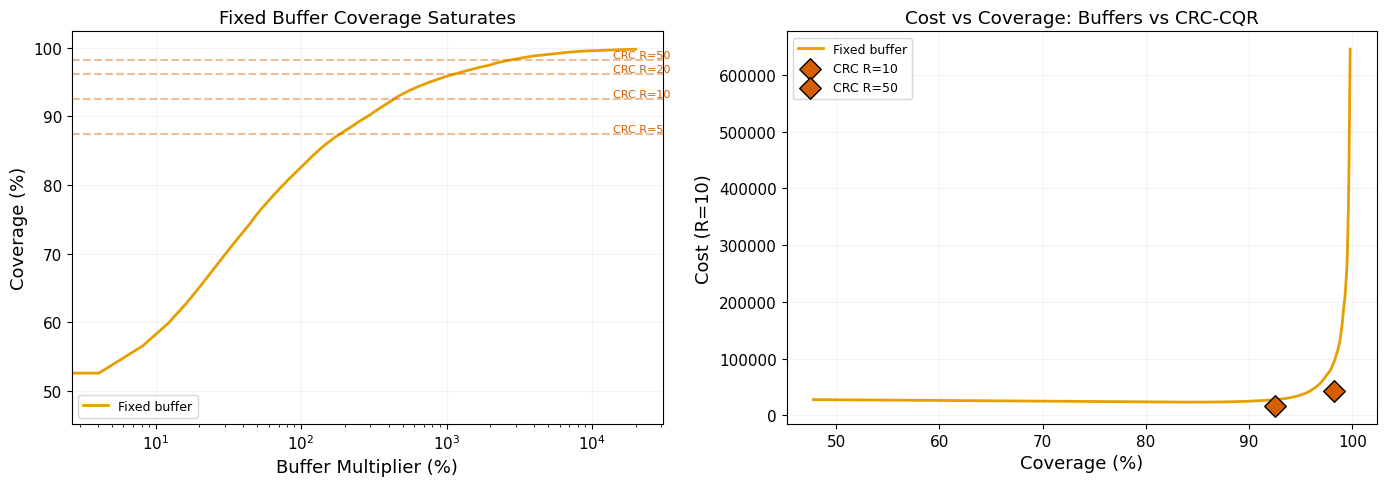

Saved buffer_saturation.png/pdf


In [ ]:
# =============================================================
# EXPERIMENT C: Coverage vs buffer multiplier (to very large)
# =============================================================
# Show what happens when you push fixed buffers to extreme multipliers.
# Does coverage asymptote? Where? Why?

print("=" * 70)
print("COVERAGE vs BUFFER MULTIPLIER (extreme range)")
print("=" * 70)

buf_multipliers = np.concatenate([
    np.linspace(0, 2, 50),
    np.linspace(2, 10, 50),
    np.linspace(10, 50, 30),
    np.linspace(50, 200, 20),
])
buf_multipliers = np.unique(buf_multipliers)

print(f"\n  {'Buffer %':>10} {'Coverage':>10} {'Viol%':>8} {'Cost(R=10)':>12} {'Mean Alloc':>12}")
print(f"  {'-'*55}")

# Track key milestones
milestones = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]
buf_cov_data = []

for buf in buf_multipliers:
    alloc = pred_med_te * (1 + buf)
    cov = (y_te_sec <= alloc).mean()
    viol = 1 - cov
    cost = compute_cost(alloc, y_te_sec, 10.0).mean()
    buf_cov_data.append({"buf": buf, "cov": cov, "viol": viol, "cost": cost,
                          "mean_alloc": alloc.mean()})
    if buf in milestones or abs(buf - round(buf)) < 0.01 and buf <= 10:
        if buf in milestones:
            print(f"  {buf*100:>9.0f}% {cov:>9.1%} {viol*100:>7.1f}% "
                  f"{cost:>11,.0f} {alloc.mean():>11,.0f}s")

# Find the asymptote
max_cov = max(d["cov"] for d in buf_cov_data)
print(f"\n  Maximum coverage achievable by any buffer: {max_cov:.4%}")
print(f"  At buffer = {max(d['buf'] for d in buf_cov_data if d['cov'] >= max_cov - 0.0001)*100:.0f}%")

# Why can't buffers reach 100%?
# Find jobs that are NEVER covered even at 200x buffer
alloc_extreme = pred_med_te * 201  # 20000% buffer
still_violated = y_te_sec > alloc_extreme
print(f"\n  Jobs violated even at 20000% buffer: {still_violated.sum()} ({still_violated.mean()*100:.2f}%)")
if still_violated.sum() > 0:
    print(f"  These jobs have:")
    print(f"    Median actual runtime: {np.median(y_te_sec[still_violated]):.0f}s")
    print(f"    Median predicted runtime: {np.median(pred_med_te[still_violated]):.0f}s")
    print(f"    Median ratio (actual/predicted): {np.median(y_te_sec[still_violated]/pred_med_te[still_violated]):.1f}×")
    print(f"    These are jobs where the predictor is catastrophically wrong")
    print(f"    (actual >> predicted). No multiplicative buffer can fix this.")
    print(f"    CQR handles them through ADDITIVE correction (Q term).")

# Compare: what coverage does CRC-CQR achieve at various R?
print(f"\n  CRC-CQR coverage for comparison:")
for R in R_values:
    cov_crc = crc_results[R]["cov"]
    # Find equivalent buffer
    equiv_buf = None
    for d in buf_cov_data:
        if d["cov"] >= cov_crc - 0.001:
            equiv_buf = d["buf"]
            break
    equiv_str = f"{equiv_buf*100:.0f}%" if equiv_buf else "N/A"
    print(f"    R={R:>2}: CRC coverage={cov_crc:.1%}, "
          f"equivalent buffer≈{equiv_str}, "
          f"CRC cost={crc_results[R]['cost']:,.0f}")

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bufs = [d["buf"]*100 for d in buf_cov_data]
covs = [d["cov"]*100 for d in buf_cov_data]
ax.plot(bufs, covs, "-", color="#E69F00", linewidth=2, label="Fixed buffer")
# Mark CRC-CQR coverages
for R in [5, 10, 20, 50]:
    cov_crc = crc_results[R]["cov"] * 100
    ax.axhline(y=cov_crc, color="#D55E00", linestyle="--", alpha=0.4)
    ax.annotate(f"CRC R={R}", xy=(max(bufs)*0.7, cov_crc+0.3), fontsize=8, color="#D55E00")
ax.set_xlabel("Buffer Multiplier (%)")
ax.set_ylabel("Coverage (%)")
ax.set_title("Fixed Buffer Coverage Saturates")
ax.set_xscale("log")
ax.grid(True, alpha=0.15)
ax.legend()

ax = axes[1]
costs = [d["cost"] for d in buf_cov_data]
ax.plot(covs, costs, "-", color="#E69F00", linewidth=2, label="Fixed buffer")
for R in [10, 50]:
    ax.scatter([crc_results[R]["cov"]*100], [crc_results[R]["cost"]],
               s=120, c="#D55E00", marker="D", edgecolors="black", zorder=10,
               label=f"CRC R={R}")
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("Cost (R=10)")
ax.set_title("Cost vs Coverage: Buffers vs CRC-CQR")
ax.legend()
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig("buffer_saturation.png", dpi=150, bbox_inches="tight")
plt.savefig("buffer_saturation.pdf", bbox_inches="tight")
plt.show()
print("Saved buffer_saturation.png/pdf")

In [ ]:
# =============================================================
# EXPERIMENT D: Runtime/overhead measurement
# =============================================================
import time

print("=" * 70)
print("RUNTIME & OVERHEAD MEASUREMENT")
print("=" * 70)

n_train = len(X_tr)
n_cal = len(X_cal)
n_test = len(X_te)
n_features = X_tr.shape[1] if hasattr(X_tr, 'shape') else len(FEATS)

print(f"\n  Dataset: {n_train + n_cal + n_test:,} total jobs")
print(f"  Train: {n_train:,}, Cal: {n_cal:,}, Test: {n_test:,}")
print(f"  Features: {n_features}")

# --- Model training time ---
print(f"\n  --- Model Training ---")
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

es_set_timing = [(X_va.values if hasattr(X_va, 'values') else X_va, y_va_log)]

for alpha_name, alpha_val in [("median (0.50)", 0.50), ("lo (0.05)", 0.05), ("hi (0.95)", 0.95)]:
    t0 = time.time()
    m_tmp = LGBMRegressor(
        objective="quantile", alpha=alpha_val,
        n_estimators=800, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
    m_tmp.fit(X_tr, y_tr_log, eval_set=es_set_timing,
              callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
    t1 = time.time()
    print(f"    Quantile {alpha_name}: {t1-t0:.1f}s ({m_tmp.n_estimators_} trees)")

total_train_time = 0
for alpha_val in [0.05, 0.50, 0.95]:
    t0 = time.time()
    m_tmp = LGBMRegressor(
        objective="quantile", alpha=alpha_val,
        n_estimators=800, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
    m_tmp.fit(X_tr, y_tr_log, eval_set=es_set_timing,
              callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
    total_train_time += time.time() - t0
print(f"    TOTAL training (3 models): {total_train_time:.1f}s")

# --- Prediction time ---
print(f"\n  --- Prediction (inference) ---")
t0 = time.time()
for _ in range(10):
    _ = model_med.predict(X_te)
    _ = model_lo.predict(X_te)
    _ = model_hi.predict(X_te)
t1 = time.time()
pred_time_per_run = (t1 - t0) / 10
pred_time_per_job = pred_time_per_run / n_test
print(f"    3 models on {n_test:,} jobs: {pred_time_per_run*1000:.1f}ms")
print(f"    Per-job inference: {pred_time_per_job*1e6:.1f}μs")

# --- CQR calibration time ---
print(f"\n  --- CQR Calibration ---")
t0 = time.time()
for _ in range(100):
    E = np.maximum(pred_lo_cal_log - y_cal_log, y_cal_log - pred_hi_cal_log)
    Q = np.quantile(E, 0.90)
t1 = time.time()
cqr_time = (t1 - t0) / 100
print(f"    CQR on {n_cal:,} cal points: {cqr_time*1000:.2f}ms")

# --- CRC lambda search time ---
print(f"\n  --- CRC Lambda Search ---")
t0 = time.time()
n_lambdas = len(lambdas)
for _ in range(10):
    for j, lam in enumerate(lambdas):
        alloc = mid_cal + lam * hw_cal
        mean_overrun = np.maximum(y_cal_sec - alloc, 0).mean()
        if mean_overrun <= 1000:  # dummy threshold
            break
t1 = time.time()
crc_time = (t1 - t0) / 10
print(f"    CRC search ({n_lambdas} lambdas, {n_cal:,} cal jobs): {crc_time*1000:.1f}ms")

# --- Per-bucket CRC time ---
print(f"\n  --- Per-Bucket CRC ---")
t0 = time.time()
for _ in range(10):
    for b in range(4):
        mask = (buckets_cal == b)
        if mask.sum() < 50:
            continue
        for j, lam in enumerate(lambdas):
            alloc = mid_cal[mask] + lam * hw_cal[mask]
            mean_overrun = np.maximum(y_cal_sec[mask] - alloc, 0).mean()
            if mean_overrun <= 1000:
                break
t1 = time.time()
bucket_crc_time = (t1 - t0) / 10
print(f"    4-bucket CRC search: {bucket_crc_time*1000:.1f}ms")

# --- Online λ selection (per new job) ---
print(f"\n  --- Per-Job Allocation (online) ---")
t0 = time.time()
for _ in range(1000):
    # Simulate: given λ, compute allocation for one job
    lam = 1.5
    alloc_single = mid_te[0] + lam * hw_te[0]
t1 = time.time()
online_time = (t1 - t0) / 1000
print(f"    Per-job allocation (given λ): {online_time*1e9:.0f}ns")

# --- Summary ---
print(f"\n  {'='*50}")
print(f"  OVERHEAD SUMMARY")
print(f"  {'='*50}")
print(f"  Training (3 LightGBM models):  {total_train_time:.0f}s (one-time)")
print(f"  CQR calibration:               {cqr_time*1000:.1f}ms (one-time)")
print(f"  CRC lambda search:             {crc_time*1000:.0f}ms (one-time per R)")
print(f"  Per-bucket CRC:                {bucket_crc_time*1000:.0f}ms (one-time per R)")
print(f"  Per-job prediction (3 models): {pred_time_per_job*1e6:.1f}μs")
print(f"  Per-job allocation (given λ):  {online_time*1e9:.0f}ns")
print(f"  ")
print(f"  Total offline setup: ~{total_train_time + crc_time + cqr_time:.0f}s")
print(f"  Online per-job cost: ~{pred_time_per_job*1e6:.0f}μs (dominated by LightGBM predict)")
print(f"  At 1000 jobs/sec arrival rate: {pred_time_per_job*1000*1000:.1f}ms/sec = negligible")

RUNTIME & OVERHEAD MEASUREMENT

  Dataset: 622,501 total jobs
  Train: 402,795, Cal: 109,852, Test: 109,854
  Features: 31

  --- Model Training ---
    Quantile median (0.50): 20.2s (141 trees)
    Quantile lo (0.05): 27.9s (281 trees)
    Quantile hi (0.95): 18.6s (172 trees)
    TOTAL training (3 models): 67.1s

  --- Prediction (inference) ---
    3 models on 109,854 jobs: 4584.6ms
    Per-job inference: 41.7μs

  --- CQR Calibration ---
    CQR on 109,852 cal points: 2.75ms

  --- CRC Lambda Search ---
    CRC search (2000 lambdas, 109,852 cal jobs): 80.4ms

  --- Per-Bucket CRC ---
    4-bucket CRC search: 1552.4ms

  --- Per-Job Allocation (online) ---
    Per-job allocation (given λ): 593ns

  OVERHEAD SUMMARY
  Training (3 LightGBM models):  67s (one-time)
  CQR calibration:               2.7ms (one-time)
  CRC lambda search:             80ms (one-time per R)
  Per-bucket CRC:                1552ms (one-time per R)
  Per-job prediction (3 models): 41.7μs
  Per-job allocation (

In [ ]:
# =====================================================================
# MAX-STRETCH: CRC-CQR vs ATLAS EDF-P (MULTI-TRIAL AVERAGING)
# =====================================================================
import heapq, time
import numpy as np
from collections import defaultdict

EPS_MS = 1e-9

def edf_schedule(r, p_true, d):
    """Standard preemptive EDF scheduler (Run-to-completion)."""
    n = len(r)
    rem = p_true.copy()
    C = np.full(n, np.nan, dtype=np.float64)
    heap = [] # Stores tuples of (deadline, job_idx)
    i, t = 0, 0.0

    while i < n or heap:
        if not heap and i < n and t < r[i]:
            t = r[i]
        while i < n and r[i] <= t + 1e-9:
            heapq.heappush(heap, (d[i], i))
            i += 1
        if not heap:
            continue

        dj, j = heapq.heappop(heap)
        next_arr = r[i] if i < n else float('inf')
        dt = min(rem[j], next_arr - t)

        rem[j] -= dt
        t += dt

        if rem[j] <= 1e-9:
            C[j] = t
        else:
            heapq.heappush(heap, (dj, j))
    return C

def edf_feasible(r, p, d):
    """EDF feasibility check (for S* bisection only)."""
    n = len(r)
    rem = p.copy()
    heap = []
    i, t = 0, 0.0
    while i < n or heap:
        if not heap and i < n:
            t = max(t, r[i])
        while i < n and r[i] <= t + EPS_MS:
            heapq.heappush(heap, (d[i], i)); i += 1
        if not heap:
            if i < n:
                t = r[i]; continue
            break
        dj, j = heapq.heappop(heap)
        if t > dj + EPS_MS:
            return False
        next_arr = r[i] if i < n else 1e18
        dt = min(rem[j], next_arr - t, dj - t)
        if dt <= 1e-12:
            t = next_arr
            if rem[j] > EPS_MS:
                heapq.heappush(heap, (dj, j))
            continue
        rem[j] -= dt; t += dt
        if rem[j] > EPS_MS:
            if t >= dj - EPS_MS:
                return False
            heapq.heappush(heap, (dj, j))
    return True

def opt_max_stretch(r, p, tol=1e-3):
    def feasible(S):
        dd = r + S * p
        if np.sum(p) > (np.max(dd) - r[0]) + 1e-12:
            return False
        return edf_feasible(r, p, dd)
    lo, hi = 1.0, 2.0
    while not feasible(hi):
        hi *= 2.0
        if hi > 1e12:
            raise RuntimeError("Failed to bracket S*")
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if feasible(mid): hi = mid
        else: lo = mid
        if hi - lo <= tol * max(1.0, hi):
            break
    return hi

def stretch_metrics(r, C, p, normS):
    s = np.maximum((C - r) / np.maximum(p, EPS_MS), 1.0)
    return {
        "max": float(np.max(s)), "p99": float(np.percentile(s, 99)),
        "p95": float(np.percentile(s, 95)), "median": float(np.median(s)),
        "rho_max": float(np.max(s) / normS),
        "rho_99": float(np.percentile(s, 99) / normS),
        "rho_med": float(np.median(s) / normS),
    }

# =====================================================================
# PREPARE & MULTI-TRIAL EXECUTION
# =====================================================================
STRETCH_N = 5000
NUM_TRIALS = 50
RESTART_PENALTY_SEC =0 # Assume 15 min penalty to reload checkpoints/data

print("=" * 90)
print(f"MAX-STRETCH: CRC-CQR vs ATLAS EDF-P ({NUM_TRIALS} Trials, N={STRETCH_N})")
print("=" * 90)

rng_ms = np.random.RandomState(42)
agg_results = defaultdict(lambda: defaultdict(list))
t_start_all = time.time()

for trial in range(NUM_TRIALS):
    print(f"\n--- Starting Trial {trial + 1}/{NUM_TRIALS} ---")

    pick = np.sort(rng_ms.choice(len(y_te_sec), size=STRETCH_N, replace=False))
    sort_idx = np.argsort(sub_times_te[pick])
    final_idx = pick[sort_idx]

    r0 = sub_times_te[final_idx].min()
    r = (sub_times_te[final_idx] - r0).astype(np.float64)
    p_true = np.maximum(y_te_sec[final_idx], 1.0).astype(np.float64)

    # Base point prediction used by ATLAS
    #q = np.clip(np.maximum(pred_med_te[final_idx], 1.0), 0.1*p_true, 10.0*p_true)
    q = np.maximum(pred_med_te[final_idx], 1.0)

    t0 = time.time()
    S_star = opt_max_stretch(r, p_true)
    C_opt = edf_schedule(r, p_true, r + S_star * p_true)
    normS = float(np.max(np.maximum((C_opt - r)/np.maximum(p_true, 1e-9), 1.0)))
    print(f"  S*={S_star:.4f}, OPT S_max={normS:.4f} ({time.time()-t0:.1f}s)")

    # ALL methods use the same ATLAS deadline heuristic to guarantee fair queue ordering.
    # The differentiator is the Effective Processing Time due to kills.
    shared_deadline = r + S_star * q

    methods = []

    # Helper function to compute effective processing time with kills
    def compute_effective_p(allocations):
        p_eff = p_true.copy()
        killed = p_true > allocations
        # If killed: time wasted + penalty + time needed to finally complete it
        p_eff[killed] = allocations[killed] + RESTART_PENALTY_SEC + p_true[killed]
        return p_eff

    # 1. ATLAS (Fixed Buffers)
    for buf in [0.0, 0.5, 1.0, 2.0, 3.0]: # 0.0 is base ATLAS
        alloc_buf = (1 + buf) * q
        p_eff = compute_effective_p(alloc_buf)
        name = "EDF-P (ATLAS)" if buf == 0.0 else f"Buf {buf:.0%}"
        methods.append((name, p_eff, shared_deadline))

    # 2. Your Methods
    for R in R_values:
        crc_alloc = np.maximum(crc_results[R]["alloc_te"][final_idx], 1.0)
        methods.append((f"CRC R={R}", compute_effective_p(crc_alloc), shared_deadline))

        dirq_alloc = np.maximum(direct_q_results[R]["alloc_te"][final_idx], 1.0)
        methods.append((f"DirQ R={R}", compute_effective_p(dirq_alloc), shared_deadline))

        bkt_alloc = np.maximum(bucket_crc_results[R]["alloc_te"][final_idx], 1.0)
        methods.append((f"BktCRC R={R}", compute_effective_p(bkt_alloc), shared_deadline))

    # Run simulations
    t_trial = time.time()
    for name, p_eff, d_vec in methods:
        # We pass p_eff to the environment so it simulates the massive delays of killed jobs
        C = edf_schedule(r, p_eff, d_vec)

        # We evaluate stretch using p_true, because the user only cares about actual work done
        metrics = stretch_metrics(r, C, p_true, normS)
        for key, val in metrics.items():
            agg_results[name][key].append(val)

    print(f"  Trial {trial + 1} completed in {time.time()-t_trial:.1f}s")

# =====================================================================
# AVERAGING
# =====================================================================
# Compute the mean of each metric for each method
results = {}
for name, metrics_dict in agg_results.items():
    results[name] = {k: np.mean(v) for k, v in metrics_dict.items()}

# =====================================================================
# TABLES (Using Averaged Results)
# =====================================================================
print(f"\n{'='*90}")
print(f"AVERAGED RESULTS OVER {NUM_TRIALS} TRIALS (N={STRETCH_N})")
print(f"{'='*90}")
print(f"{'Method':<22} {'S_max':>9} {'S_99':>9} {'S_med':>9}  {'rho_max':>8} {'rho_99':>8} {'rho_med':>8}")
print(f"{'-'*75}")
for name in ["OPT", "EDF-P (ATLAS)"] + [f"Buf {b:.0%}" for b in [0.5, 1.0, 2.0, 3.0]]:
    if name in results:
        m = results[name]
        print(f"{name:<22} {m['max']:>9.2f} {m['p99']:>9.2f} {m['median']:>9.2f}"
              f"  {m['rho_max']:>8.3f} {m['rho_99']:>8.3f} {m['rho_med']:>8.3f}")

for R in R_values:
    print(f"\n  R={R}:")
    for name in [f"CRC R={R}", f"DirQ R={R}", f"BktCRC R={R}"]:
        if name in results:
            m = results[name]
            tag = ">>>" if name.startswith("CRC") else "   "
            print(f"  {tag}{name:<19} {m['max']:>9.2f} {m['p99']:>9.2f} {m['median']:>9.2f}"
                  f"  {m['rho_max']:>8.3f} {m['rho_99']:>8.3f} {m['rho_med']:>8.3f}")

# Compact cross-R
print(f"\n{'='*90}")
print(f"AVERAGED rho_max across R:")
print(f"  {'Method':<20}", end="")
for R in R_values:
    print(f" R={R:>3}", end="")
print()
print(f"  {'-'*55}")
for prefix, label in [("CRC", "CRC-CQR"), ("DirQ", "Direct Q"), ("BktCRC", "Bucket CRC")]:
    print(f"  {label:<20}", end="")
    for R in R_values:
        name = f"{prefix} R={R}"
        if name in results:
            print(f" {results[name]['rho_max']:>5.2f}", end="")
        else:
            print(f"   ---", end="")
    print()
m = results["EDF-P (ATLAS)"]
print(f"  {'EDF-P (ATLAS)':<20}", end="")
for R in R_values:
    print(f" {m['rho_max']:>5.2f}", end="")
print()

# rho_99
print(f"\n  AVERAGED rho_99 across R:")
print(f"  {'Method':<20}", end="")
for R in R_values:
    print(f" R={R:>3}", end="")
print()
print(f"  {'-'*55}")
for prefix, label in [("CRC", "CRC-CQR"), ("DirQ", "Direct Q"), ("BktCRC", "Bucket CRC")]:
    print(f"  {label:<20}", end="")
    for R in R_values:
        name = f"{prefix} R={R}"
        if name in results:
            print(f" {results[name]['rho_99']:>5.2f}", end="")
        else:
            print(f"   ---", end="")
    print()
m = results["EDF-P (ATLAS)"]
print(f"  {'EDF-P (ATLAS)':<20}", end="")
for R in R_values:
    print(f" {m['rho_99']:>5.2f}", end="")
print()

MAX-STRETCH: CRC-CQR vs ATLAS EDF-P (50 Trials, N=5000)

--- Starting Trial 1/50 ---
  S*=380.7568, OPT S_max=380.5938 (0.4s)
  Trial 1 completed in 0.6s

--- Starting Trial 2/50 ---
  S*=400.7178, OPT S_max=400.6310 (0.4s)
  Trial 2 completed in 0.6s

--- Starting Trial 3/50 ---
  S*=418.4331, OPT S_max=418.4219 (0.4s)
  Trial 3 completed in 0.6s

--- Starting Trial 4/50 ---
  S*=419.6807, OPT S_max=419.4946 (0.4s)
  Trial 4 completed in 0.6s

--- Starting Trial 5/50 ---
  S*=404.9595, OPT S_max=404.8880 (0.4s)
  Trial 5 completed in 0.6s

--- Starting Trial 6/50 ---
  S*=416.9360, OPT S_max=416.8874 (0.4s)
  Trial 6 completed in 0.6s

--- Starting Trial 7/50 ---
  S*=407.4546, OPT S_max=407.4201 (0.4s)
  Trial 7 completed in 0.6s

--- Starting Trial 8/50 ---
  S*=405.4585, OPT S_max=405.4370 (0.4s)
  Trial 8 completed in 0.6s

--- Starting Trial 9/50 ---
  S*=381.7549, OPT S_max=381.7032 (0.6s)
  Trial 9 completed in 1.1s

--- Starting Trial 10/50 ---
  S*=403.7119, OPT S_max=403.507

In [ ]:
# =====================================================================
# MAX-STRETCH: CRC-CQR vs ATLAS EDF-P (MULTI-TRIAL AVERAGING)
# =====================================================================
import heapq, time
import numpy as np
from collections import defaultdict

EPS_MS = 1e-9

def edf_schedule(r, p_true, d):
    """Standard preemptive EDF scheduler (Run-to-completion)."""
    n = len(r)
    rem = p_true.copy()
    C = np.full(n, np.nan, dtype=np.float64)
    heap = [] # Stores tuples of (deadline, job_idx)
    i, t = 0, 0.0

    while i < n or heap:
        if not heap and i < n and t < r[i]:
            t = r[i]
        while i < n and r[i] <= t + 1e-9:
            heapq.heappush(heap, (d[i], i))
            i += 1
        if not heap:
            continue

        dj, j = heapq.heappop(heap)
        next_arr = r[i] if i < n else float('inf')
        dt = min(rem[j], next_arr - t)

        rem[j] -= dt
        t += dt

        if rem[j] <= 1e-9:
            C[j] = t
        else:
            heapq.heappush(heap, (dj, j))
    return C

def edf_feasible(r, p, d):
    """EDF feasibility check (for S* bisection only)."""
    n = len(r)
    rem = p.copy()
    heap = []
    i, t = 0, 0.0
    while i < n or heap:
        if not heap and i < n:
            t = max(t, r[i])
        while i < n and r[i] <= t + EPS_MS:
            heapq.heappush(heap, (d[i], i)); i += 1
        if not heap:
            if i < n:
                t = r[i]; continue
            break
        dj, j = heapq.heappop(heap)
        if t > dj + EPS_MS:
            return False
        next_arr = r[i] if i < n else 1e18
        dt = min(rem[j], next_arr - t, dj - t)
        if dt <= 1e-12:
            t = next_arr
            if rem[j] > EPS_MS:
                heapq.heappush(heap, (dj, j))
            continue
        rem[j] -= dt; t += dt
        if rem[j] > EPS_MS:
            if t >= dj - EPS_MS:
                return False
            heapq.heappush(heap, (dj, j))
    return True

def opt_max_stretch(r, p, tol=1e-3):
    def feasible(S):
        dd = r + S * p
        if np.sum(p) > (np.max(dd) - r[0]) + 1e-12:
            return False
        return edf_feasible(r, p, dd)
    lo, hi = 1.0, 2.0
    while not feasible(hi):
        hi *= 2.0
        if hi > 1e12:
            raise RuntimeError("Failed to bracket S*")
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if feasible(mid): hi = mid
        else: lo = mid
        if hi - lo <= tol * max(1.0, hi):
            break
    return hi

def stretch_metrics(r, C, p, normS):
    s = np.maximum((C - r) / np.maximum(p, EPS_MS), 1.0)
    return {
        "max": float(np.max(s)), "p99": float(np.percentile(s, 99)),
        "p95": float(np.percentile(s, 95)), "median": float(np.median(s)),
        "rho_max": float(np.max(s) / normS),
        "rho_99": float(np.percentile(s, 99) / normS),
        "rho_med": float(np.median(s) / normS),
    }

# =====================================================================
# PREPARE & MULTI-TRIAL EXECUTION (SOFT-DEADLINES / NO KILLS)
# =====================================================================
STRETCH_N = 5000
NUM_TRIALS = 50

print("=" * 90)
print(f"MAX-STRETCH: CRC-CQR vs ATLAS EDF-P ({NUM_TRIALS} Trials, N={STRETCH_N})")
print("  * NO KILLS (Soft-Deadlines): Jobs run to completion (p_true).")
print("  * QUEUE ORDERING: Deadlines are set via d_j = r_j + S* × allocation_j")
print("=" * 90)

rng_ms = np.random.RandomState(42)
agg_results = defaultdict(lambda: defaultdict(list))
t_start_all = time.time()

for trial in range(NUM_TRIALS):
    print(f"\n--- Starting Trial {trial + 1}/{NUM_TRIALS} ---")

    pick = np.sort(rng_ms.choice(len(y_te_sec), size=STRETCH_N, replace=False))
    sort_idx = np.argsort(sub_times_te[pick])
    final_idx = pick[sort_idx]

    r0 = sub_times_te[final_idx].min()
    r = (sub_times_te[final_idx] - r0).astype(np.float64)
    p_true = np.maximum(y_te_sec[final_idx], 1.0).astype(np.float64)

    # Base point prediction
    q = np.maximum(pred_med_te[final_idx], 1.0)

    t0 = time.time()
    S_star = opt_max_stretch(r, p_true)
    C_opt = edf_schedule(r, p_true, r + S_star * p_true)
    normS = float(np.max(np.maximum((C_opt - r)/np.maximum(p_true, 1e-9), 1.0)))
    print(f"  S*={S_star:.4f}, OPT S_max={normS:.4f} ({time.time()-t0:.1f}s)")

    methods = []

    # 1. ATLAS (Fixed Buffers)
    for buf in [0.0, 0.5, 1.0, 2.0, 3.0]: # 0.0 is base ATLAS
        alloc_buf = (1 + buf) * q
        # Deadline is padded by the buffer
        d_vec = r + S_star * alloc_buf
        name = "EDF-P (ATLAS)" if buf == 0.0 else f"Buf {buf:.0%}"
        methods.append((name, d_vec))

    # 2. Your Methods
    for R in R_values:
        crc_alloc = np.maximum(crc_results[R]["alloc_te"][final_idx], 1.0)
        methods.append((f"CRC R={R}", r + S_star * crc_alloc))

        dirq_alloc = np.maximum(direct_q_results[R]["alloc_te"][final_idx], 1.0)
        methods.append((f"DirQ R={R}", r + S_star * dirq_alloc))

        bkt_alloc = np.maximum(bucket_crc_results[R]["alloc_te"][final_idx], 1.0)
        methods.append((f"BktCRC R={R}", r + S_star * bkt_alloc))

    # Run simulations
    t_trial = time.time()
    for name, d_vec in methods:
        # EVERY method passes p_true (no kills).
        # The differentiator is `d_vec`, which changes queue priority.
        C = edf_schedule(r, p_true, d_vec)

        # Evaluate stretch
        metrics = stretch_metrics(r, C, p_true, normS)
        for key, val in metrics.items():
            agg_results[name][key].append(val)

    print(f"  Trial {trial + 1} completed in {time.time()-t_trial:.1f}s")

# =====================================================================
# AVERAGING
# =====================================================================
# Compute the mean of each metric for each method
results = {}
for name, metrics_dict in agg_results.items():
    results[name] = {k: np.mean(v) for k, v in metrics_dict.items()}

# =====================================================================
# TABLES (Using Averaged Results)
# =====================================================================
print(f"\n{'='*90}")
print(f"AVERAGED RESULTS OVER {NUM_TRIALS} TRIALS (N={STRETCH_N})")
print(f"{'='*90}")
print(f"{'Method':<22} {'S_max':>9} {'S_99':>9} {'S_med':>9}  {'rho_max':>8} {'rho_99':>8} {'rho_med':>8}")
print(f"{'-'*75}")
for name in ["OPT", "EDF-P (ATLAS)"] + [f"Buf {b:.0%}" for b in [0.5, 1.0, 2.0, 3.0]]:
    if name in results:
        m = results[name]
        print(f"{name:<22} {m['max']:>9.2f} {m['p99']:>9.2f} {m['median']:>9.2f}"
              f"  {m['rho_max']:>8.3f} {m['rho_99']:>8.3f} {m['rho_med']:>8.3f}")

for R in R_values:
    print(f"\n  R={R}:")
    for name in [f"CRC R={R}", f"DirQ R={R}", f"BktCRC R={R}"]:
        if name in results:
            m = results[name]
            tag = ">>>" if name.startswith("CRC") else "   "
            print(f"  {tag}{name:<19} {m['max']:>9.2f} {m['p99']:>9.2f} {m['median']:>9.2f}"
                  f"  {m['rho_max']:>8.3f} {m['rho_99']:>8.3f} {m['rho_med']:>8.3f}")

# Compact cross-R
print(f"\n{'='*90}")
print(f"AVERAGED rho_max across R:")
print(f"  {'Method':<20}", end="")
for R in R_values:
    print(f" R={R:>3}", end="")
print()
print(f"  {'-'*55}")
for prefix, label in [("CRC", "CRC-CQR"), ("DirQ", "Direct Q"), ("BktCRC", "Bucket CRC")]:
    print(f"  {label:<20}", end="")
    for R in R_values:
        name = f"{prefix} R={R}"
        if name in results:
            print(f" {results[name]['rho_max']:>5.2f}", end="")
        else:
            print(f"   ---", end="")
    print()
m = results["EDF-P (ATLAS)"]
print(f"  {'EDF-P (ATLAS)':<20}", end="")
for R in R_values:
    print(f" {m['rho_max']:>5.2f}", end="")
print()

# rho_99
print(f"\n  AVERAGED rho_99 across R:")
print(f"  {'Method':<20}", end="")
for R in R_values:
    print(f" R={R:>3}", end="")
print()
print(f"  {'-'*55}")
for prefix, label in [("CRC", "CRC-CQR"), ("DirQ", "Direct Q"), ("BktCRC", "Bucket CRC")]:
    print(f"  {label:<20}", end="")
    for R in R_values:
        name = f"{prefix} R={R}"
        if name in results:
            print(f" {results[name]['rho_99']:>5.2f}", end="")
        else:
            print(f"   ---", end="")
    print()
m = results["EDF-P (ATLAS)"]
print(f"  {'EDF-P (ATLAS)':<20}", end="")
for R in R_values:
    print(f" {m['rho_99']:>5.2f}", end="")
print()

MAX-STRETCH: CRC-CQR vs ATLAS EDF-P (50 Trials, N=5000)
  * NO KILLS (Soft-Deadlines): Jobs run to completion (p_true).
  * QUEUE ORDERING: Deadlines are set via d_j = r_j + S* × allocation_j

--- Starting Trial 1/50 ---
  S*=380.7568, OPT S_max=380.5938 (0.4s)
  Trial 1 completed in 0.6s

--- Starting Trial 2/50 ---
  S*=400.7178, OPT S_max=400.6310 (0.4s)
  Trial 2 completed in 0.6s

--- Starting Trial 3/50 ---
  S*=418.4331, OPT S_max=418.4219 (0.4s)
  Trial 3 completed in 0.6s

--- Starting Trial 4/50 ---
  S*=419.6807, OPT S_max=419.4946 (0.4s)
  Trial 4 completed in 0.6s

--- Starting Trial 5/50 ---
  S*=404.9595, OPT S_max=404.8880 (0.6s)
  Trial 5 completed in 1.1s

--- Starting Trial 6/50 ---
  S*=416.9360, OPT S_max=416.8874 (0.8s)
  Trial 6 completed in 1.0s

--- Starting Trial 7/50 ---
  S*=407.4546, OPT S_max=407.4201 (0.5s)
  Trial 7 completed in 0.6s

--- Starting Trial 8/50 ---
  S*=405.4585, OPT S_max=405.4370 (0.4s)
  Trial 8 completed in 0.6s

--- Starting Trial 9/50